---
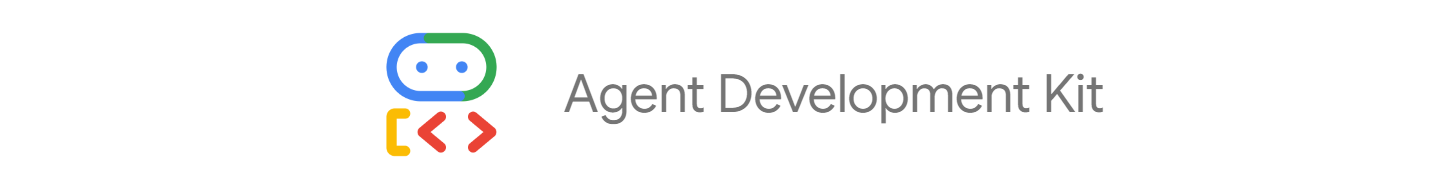

---

# ADK - Vertex AI RAG Engine Overview 👉 [Learn more](https://cloud.google.com/vertex-ai/generative-ai/docs/rag-engine/rag-overview)
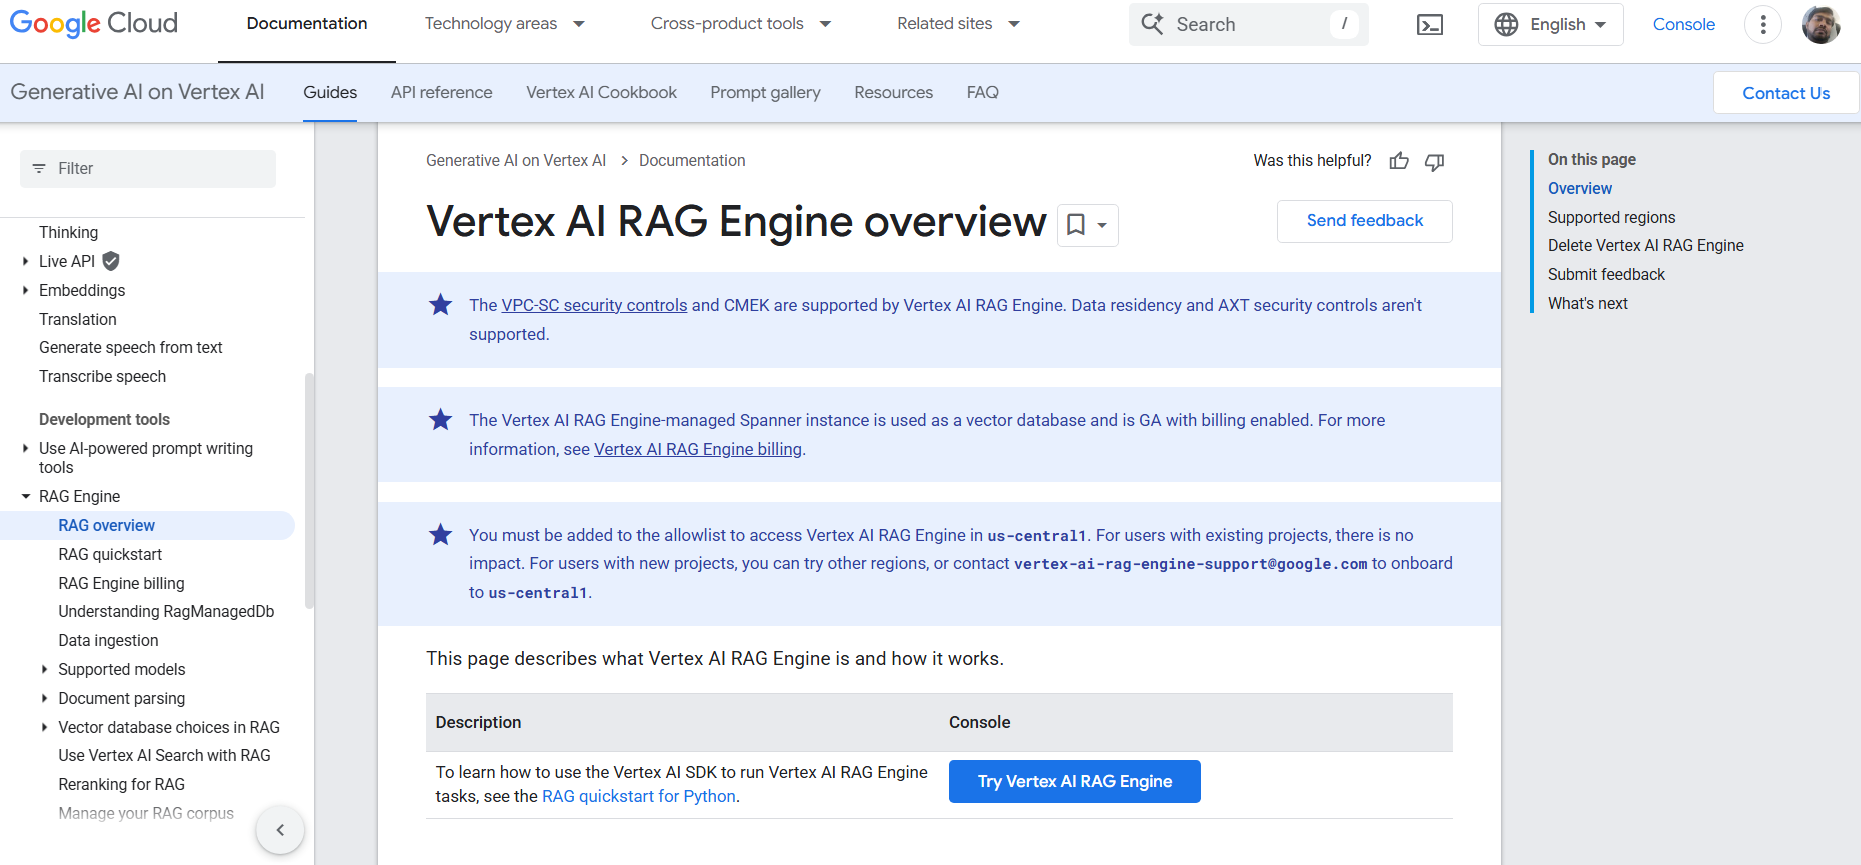

## Overview
Vertex AI RAG Engine, a component of the Vertex AI Platform, facilitates Retrieval-Augmented Generation (RAG). Vertex AI RAG Engine is also a data framework for developing context-augmented large language model (LLM) applications. Context augmentation occurs when you apply an LLM to your data. This implements retrieval-augmented generation (RAG). <br>

A common problem with LLMs is that they don't understand private knowledge, that is, your organization's data. With Vertex AI RAG Engine, you can enrich the LLM context with additional private information, because the model can reduce hallucination and answer questions more accurately.<br>

By combining additional knowledge sources with the existing knowledge that LLMs have, a better context is provided. The improved context along with the query enhances the quality of the LLM's response.<br>

The following image illustrates the key concepts to understanding `Vertex AI RAG Engine`.<br>

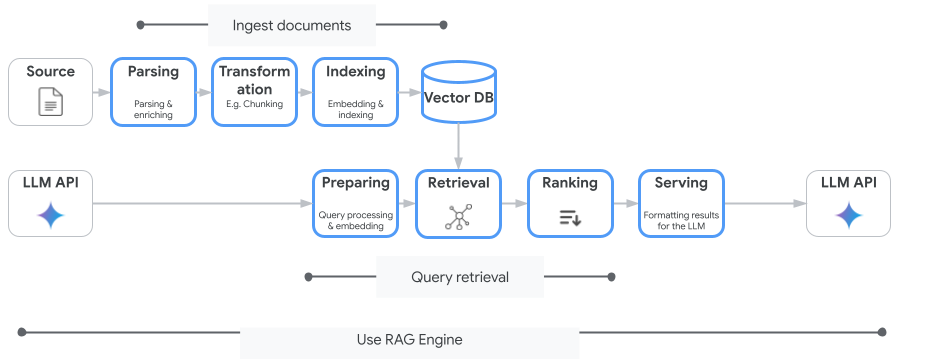 <br>

These concepts are listed in the order of the **retrieval-augmented generation (RAG)** process.

1. **Data ingestion:** Intake data from different data sources. For example, local files, Cloud Storage, and Google Drive.

1. [Data transformation](https://cloud.google.com/vertex-ai/generative-ai/docs/rag-engine/fine-tune-rag-transformations): Conversion of the data in preparation for indexing. For example, data is split into chunks. <br><br> 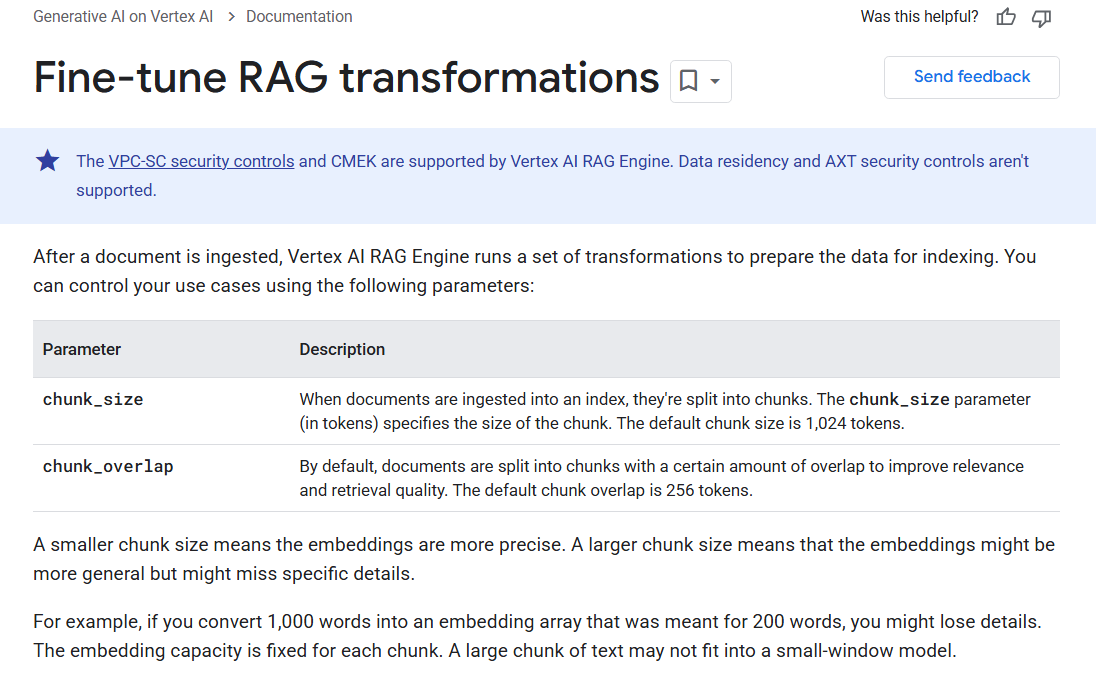

1. [Embedding](https://cloud.google.com/vertex-ai/generative-ai/docs/embeddings/get-text-embeddings): Numerical representations of words or pieces of text. These numbers capture the semantic meaning and context of the text. Similar or related words or text tend to have similar embeddings, which means they are closer together in the high-dimensional vector space. <br><br> 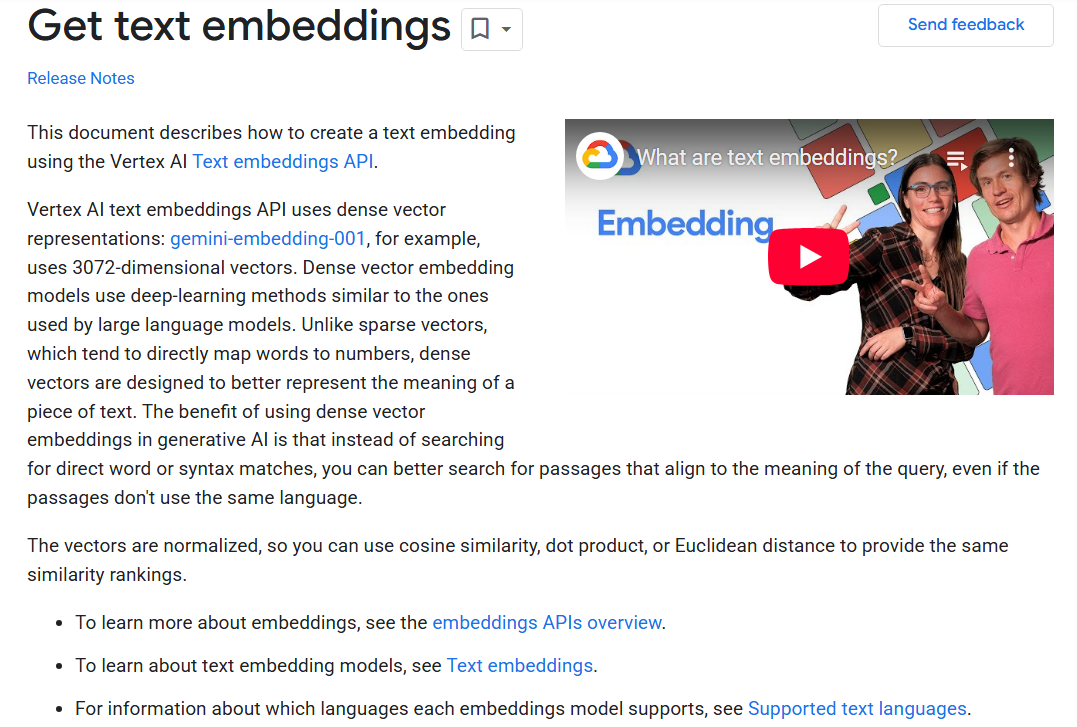

1. **Data indexing:** Vertex AI RAG Engine creates an index called a corpus. The index structures the knowledge base so it's optimized for searching. For example, the index is like a detailed table of contents for a massive reference book.

1. **Retrieval:** When a user asks a question or provides a prompt, the retrieval component in Vertex AI RAG Engine searches through its knowledge base to find information that is relevant to the query.

1. **Generation:** The retrieved information becomes the context added to the original user query as a guide for the generative AI model to generate factually grounded and relevant responses. <br><br>

For more information, refer to the public documentation for [Vertex AI RAG Engine](https://cloud.google.com/vertex-ai/generative-ai/docs/rag-engine/rag-overview). <br><br>

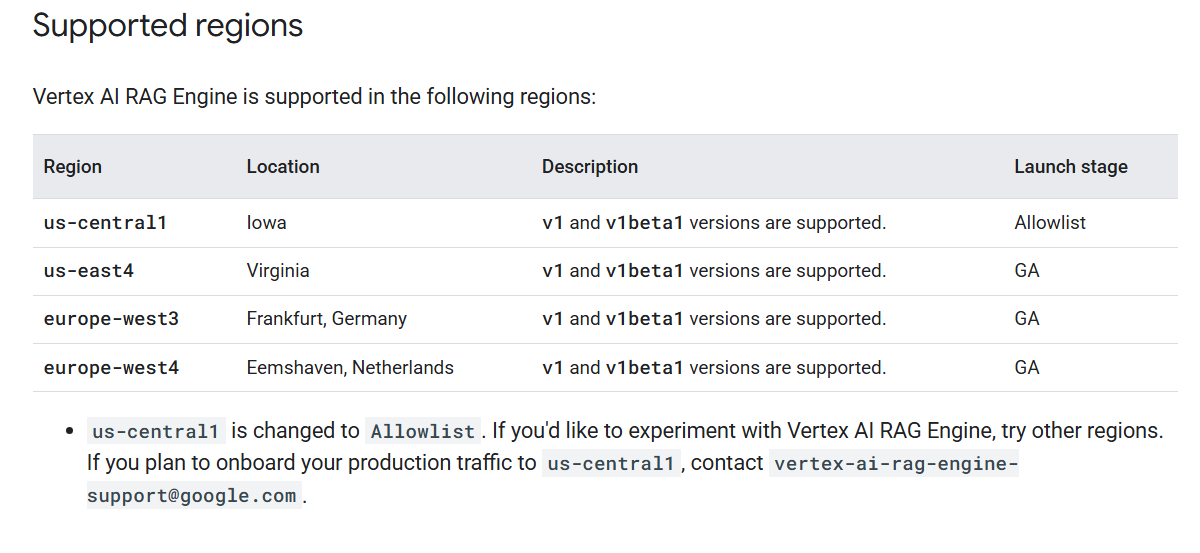 <br><br> 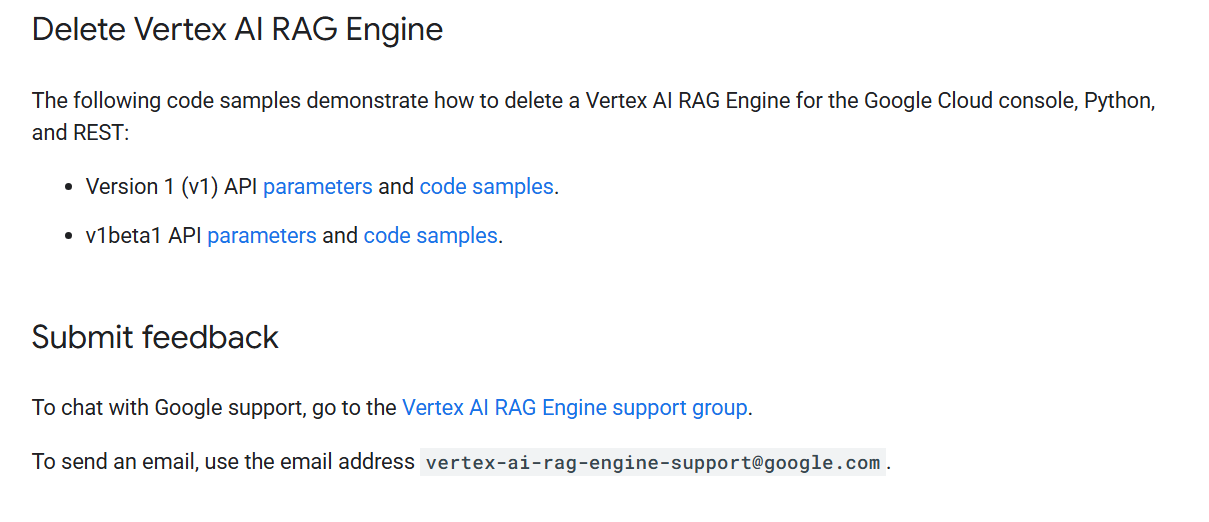 <br><br> 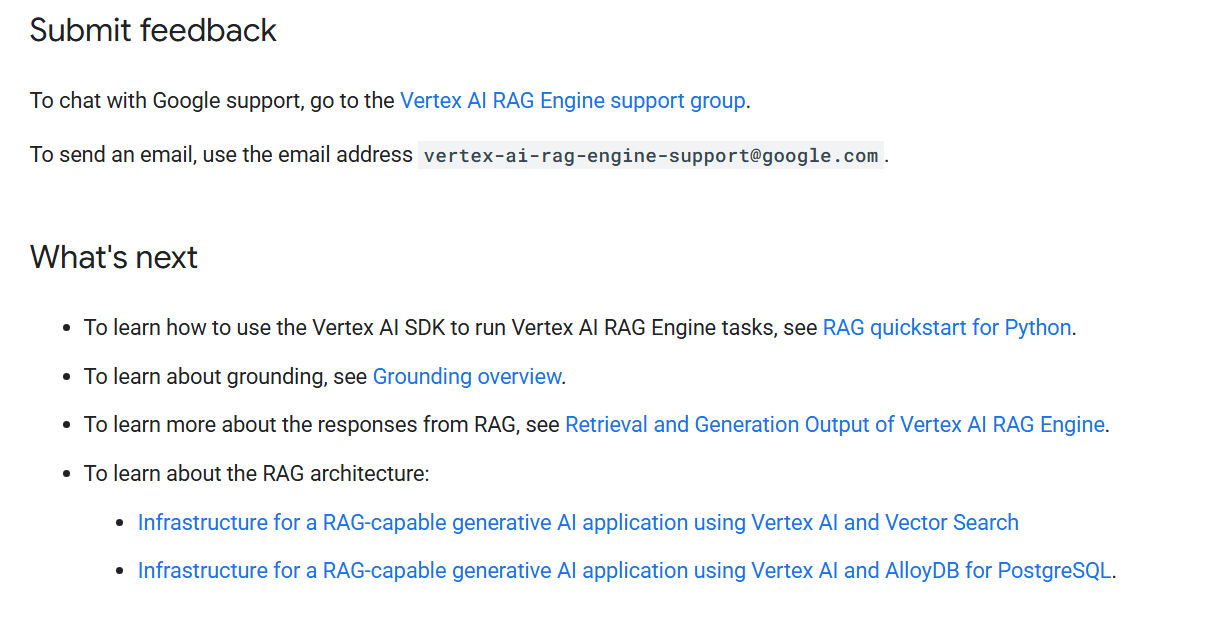

---

## Google Cloud 👉 Console 👉 🔍 RAG Engine
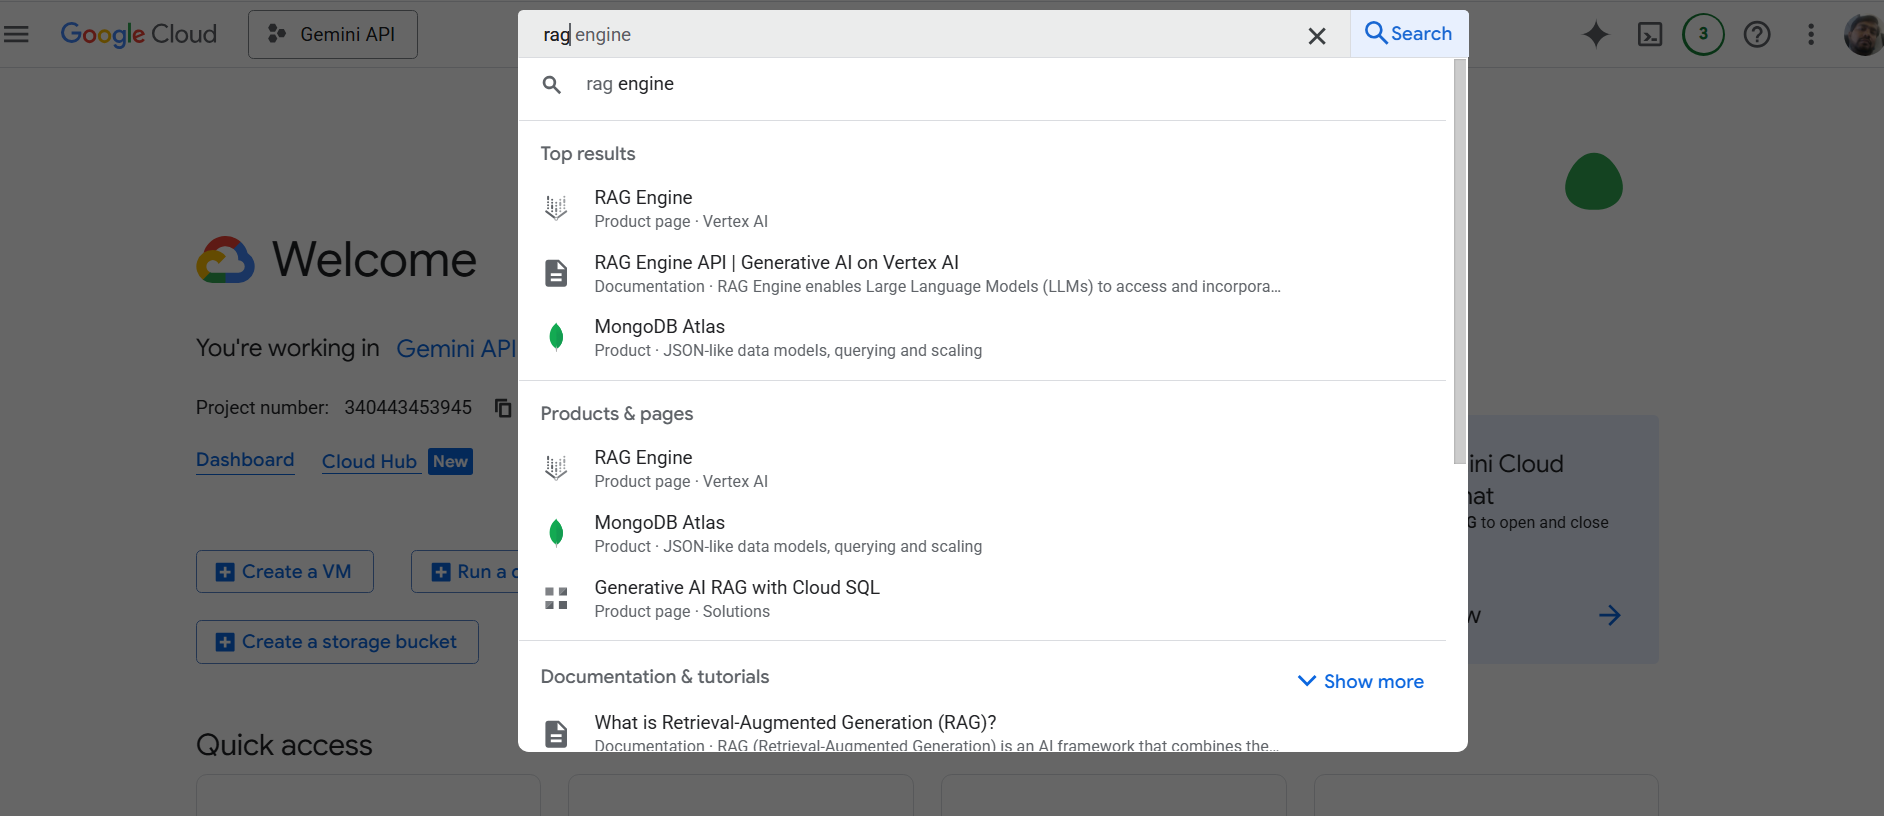 <br><br> 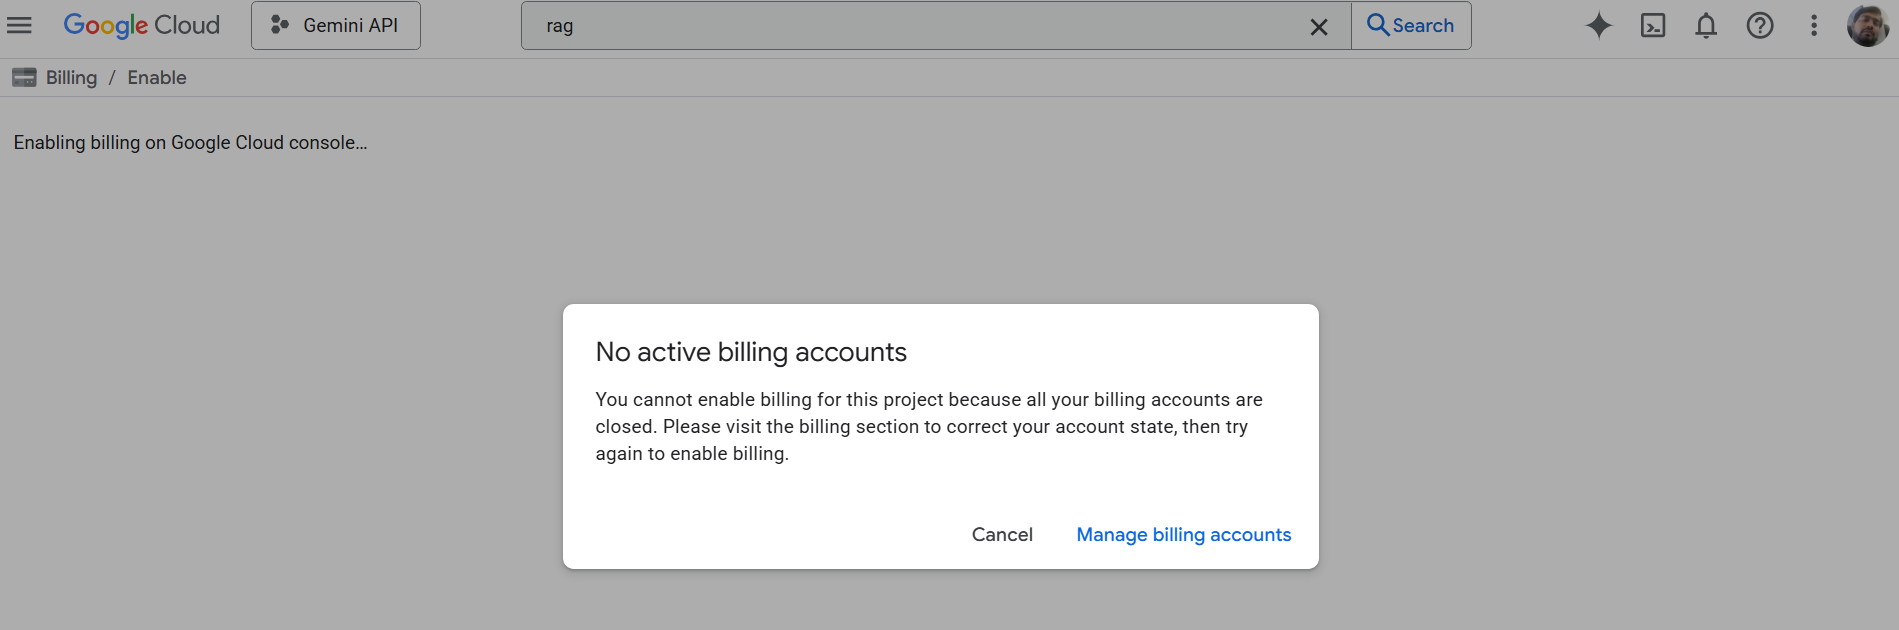

---

## Interactive RAG Playground 👉 [Learn more](https://ragplay.vercel.app/)
Debug, visualize, and master Retrieval-Augmented Generation through hands-on experiments and real-time demonstrations.

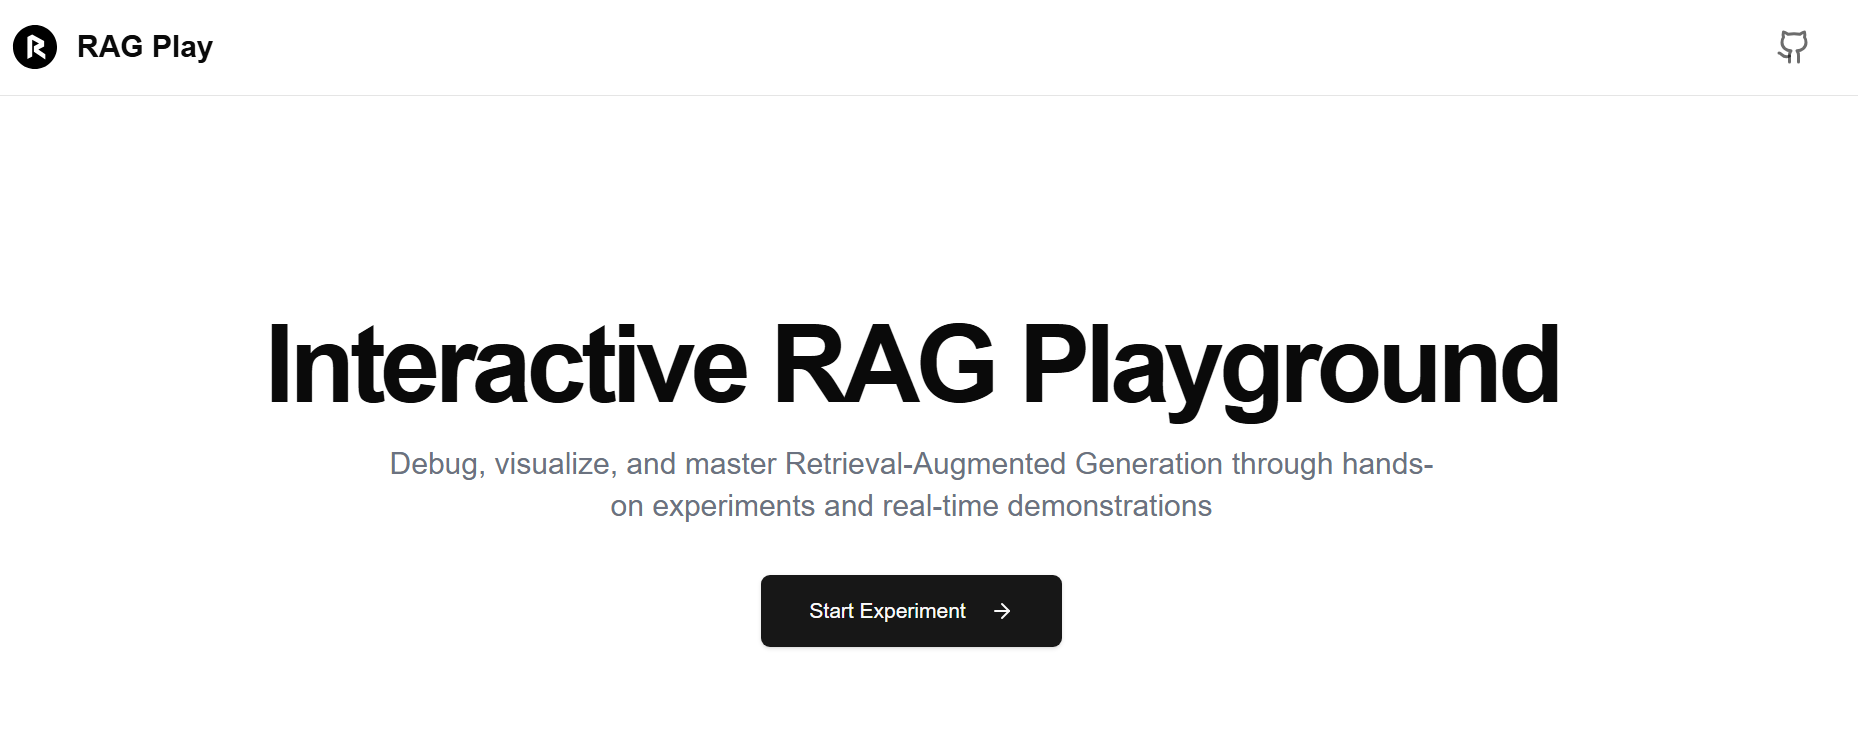

### Start Experiment
#### 1. Text Splitting
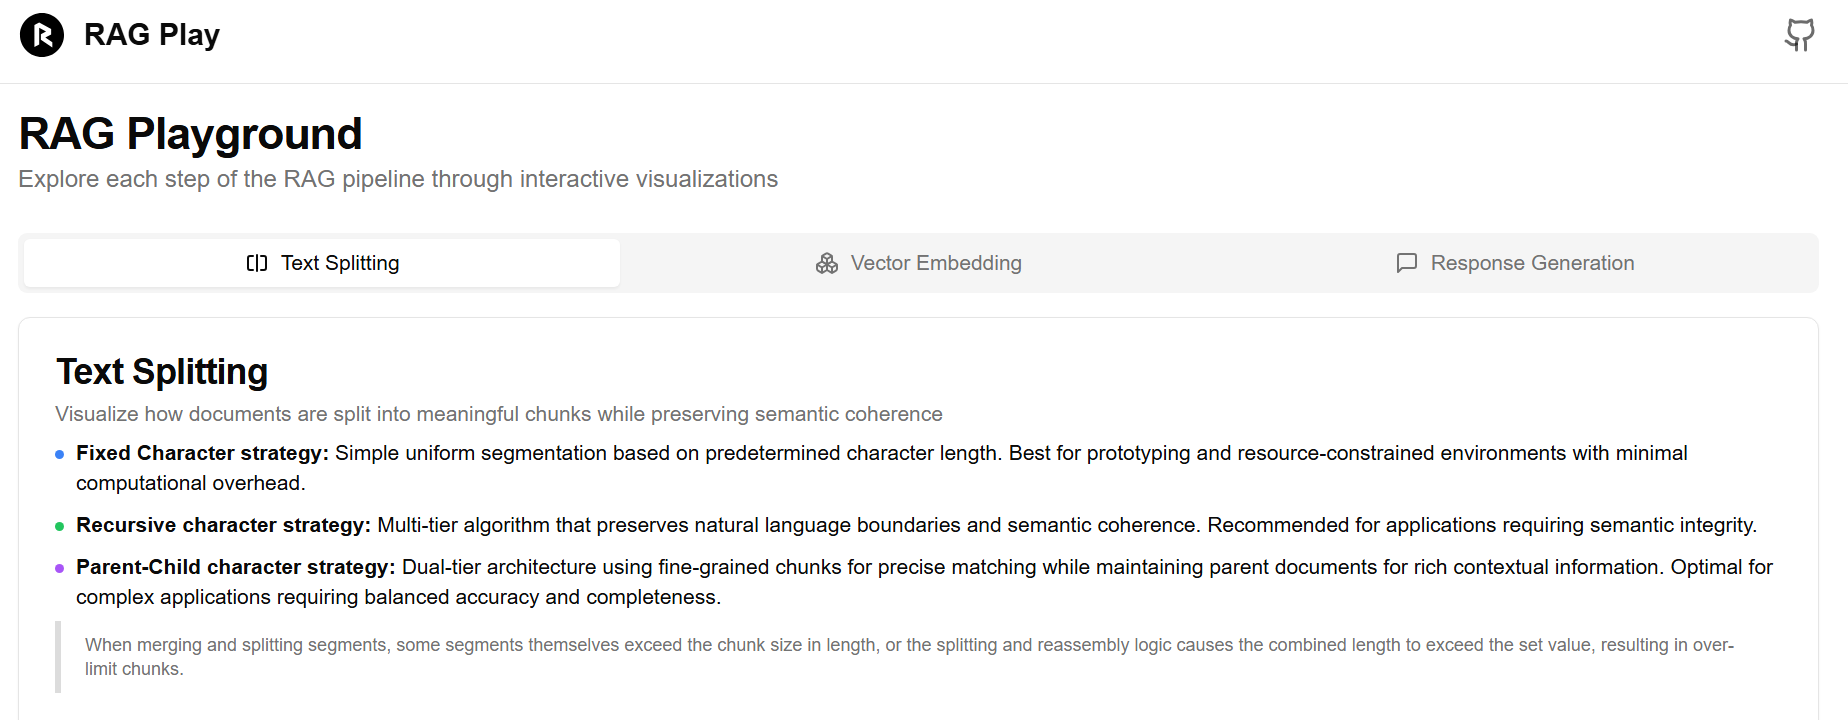 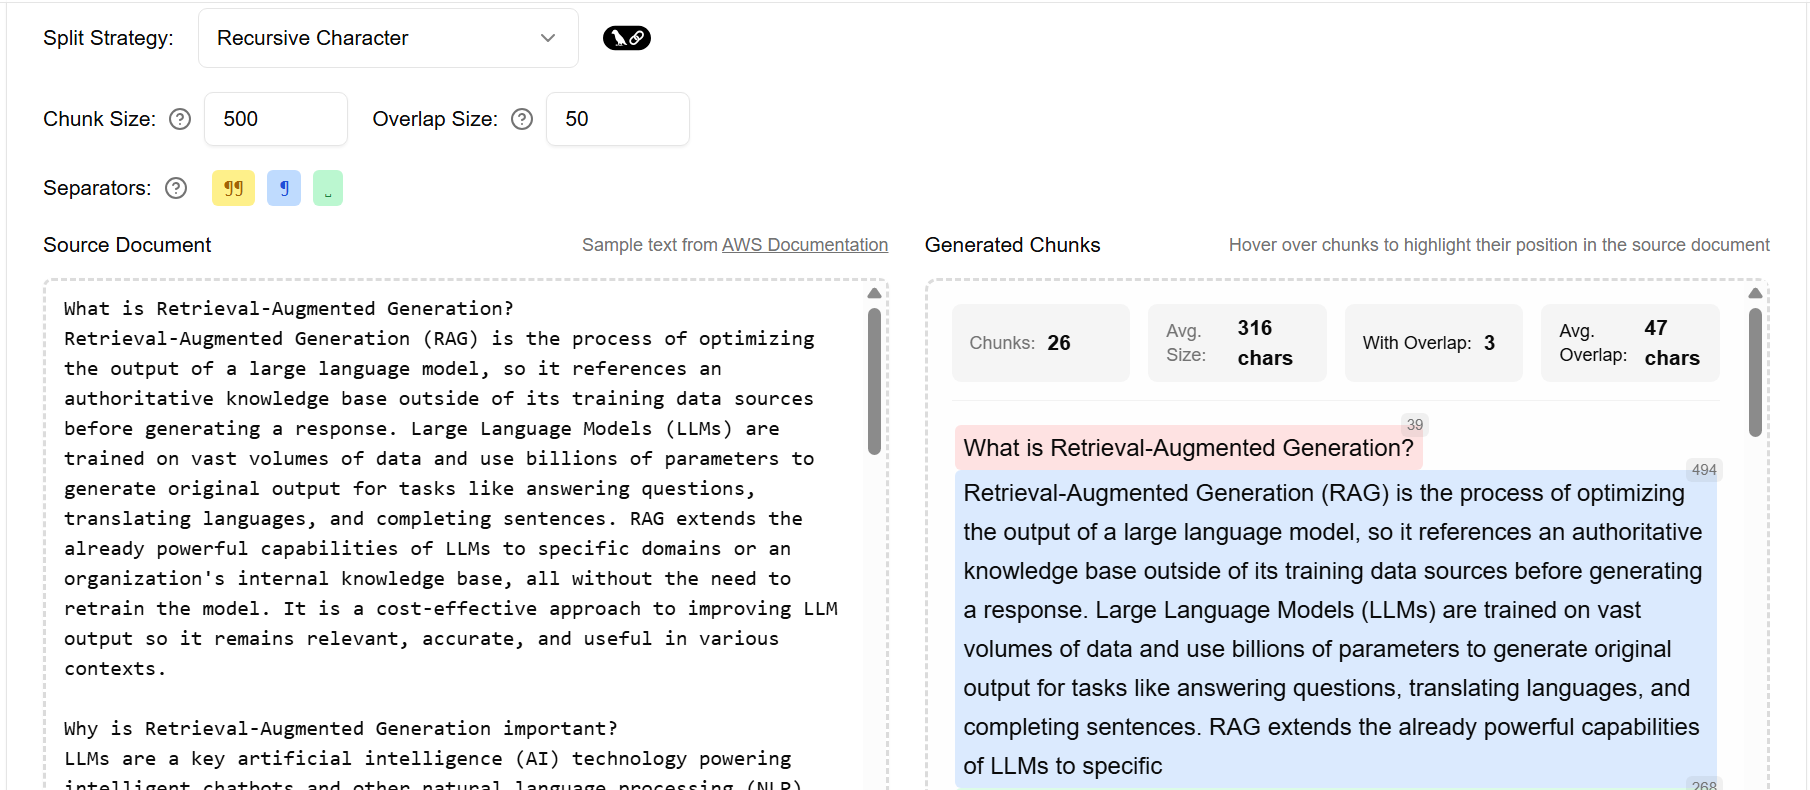 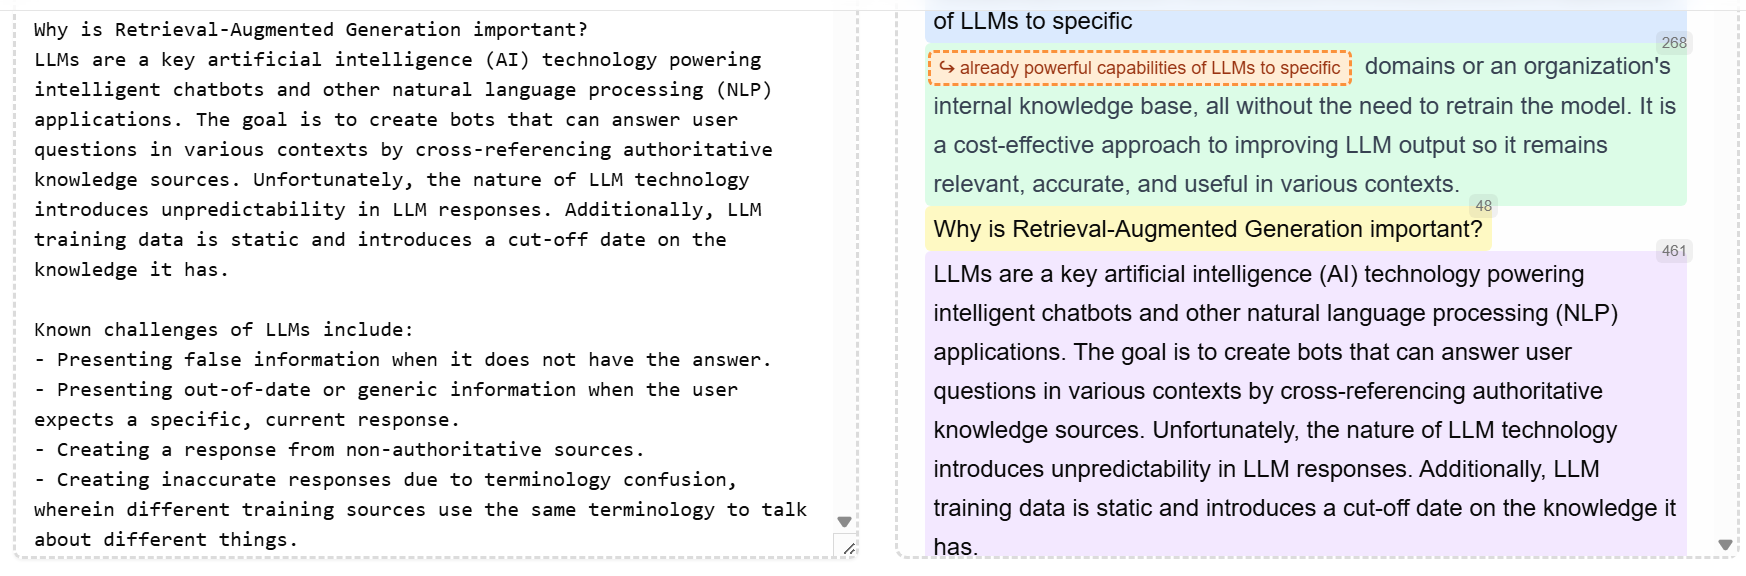 <br><br>

---

#### 2. Vector Embedding
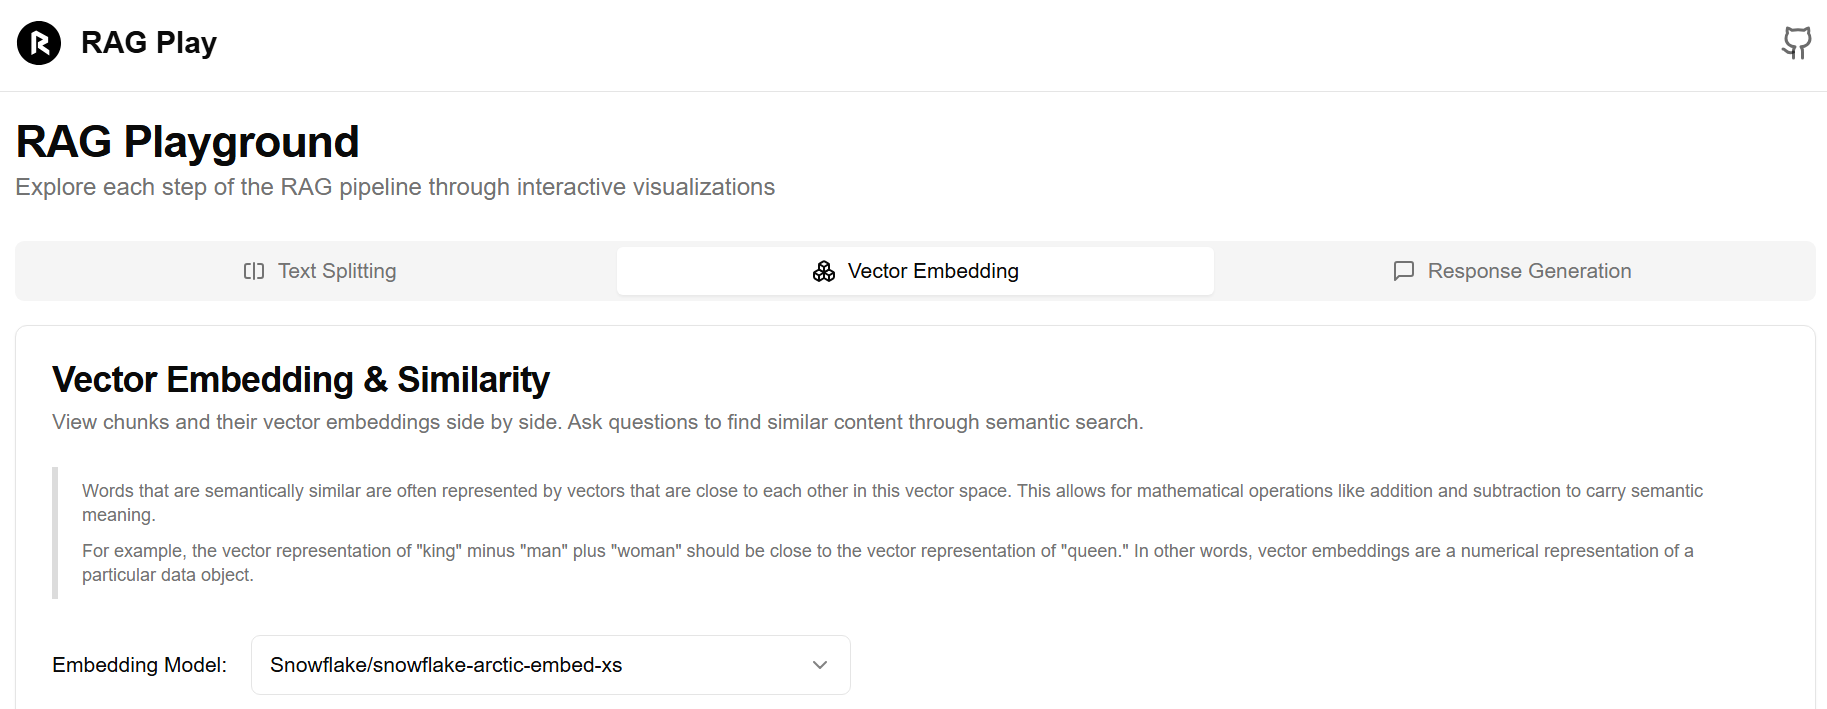 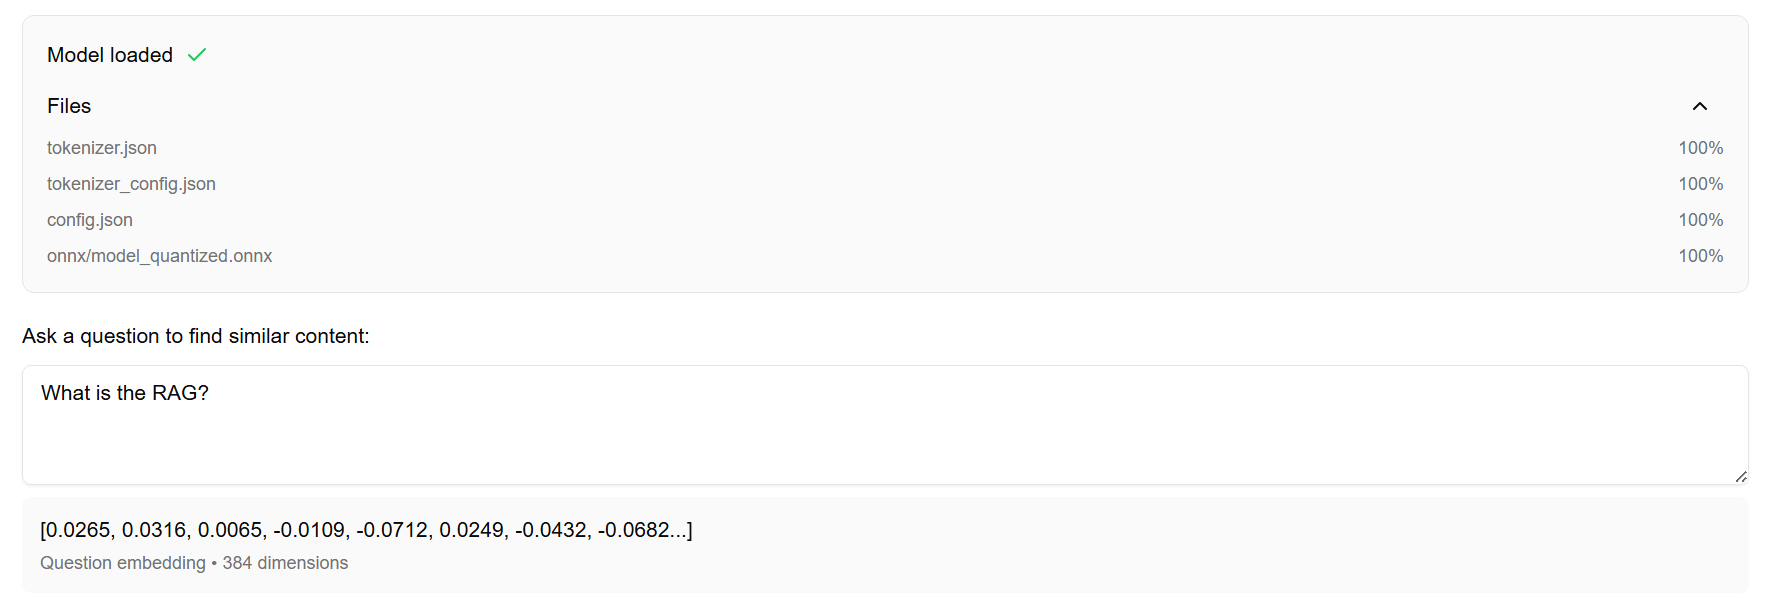 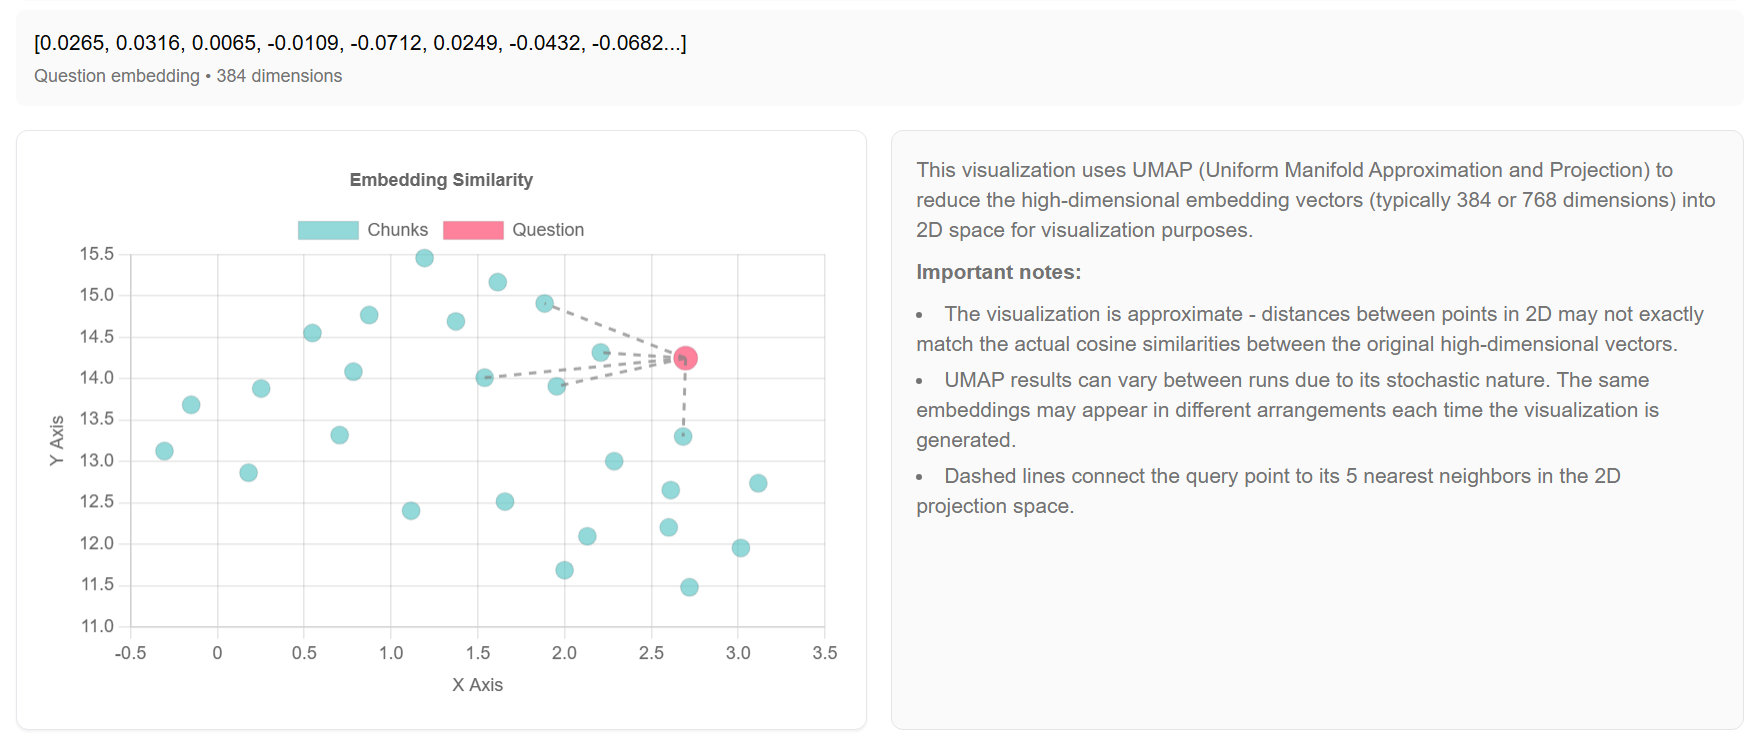 
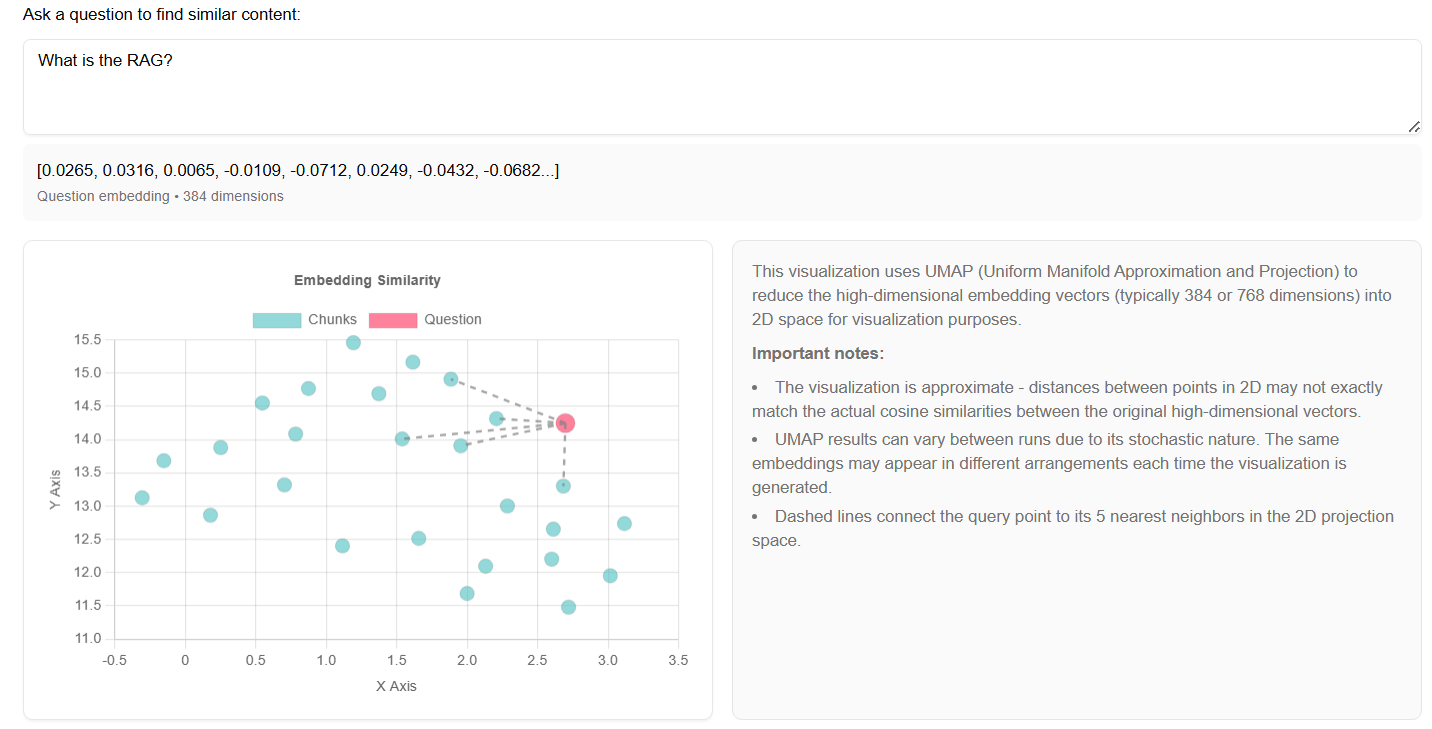 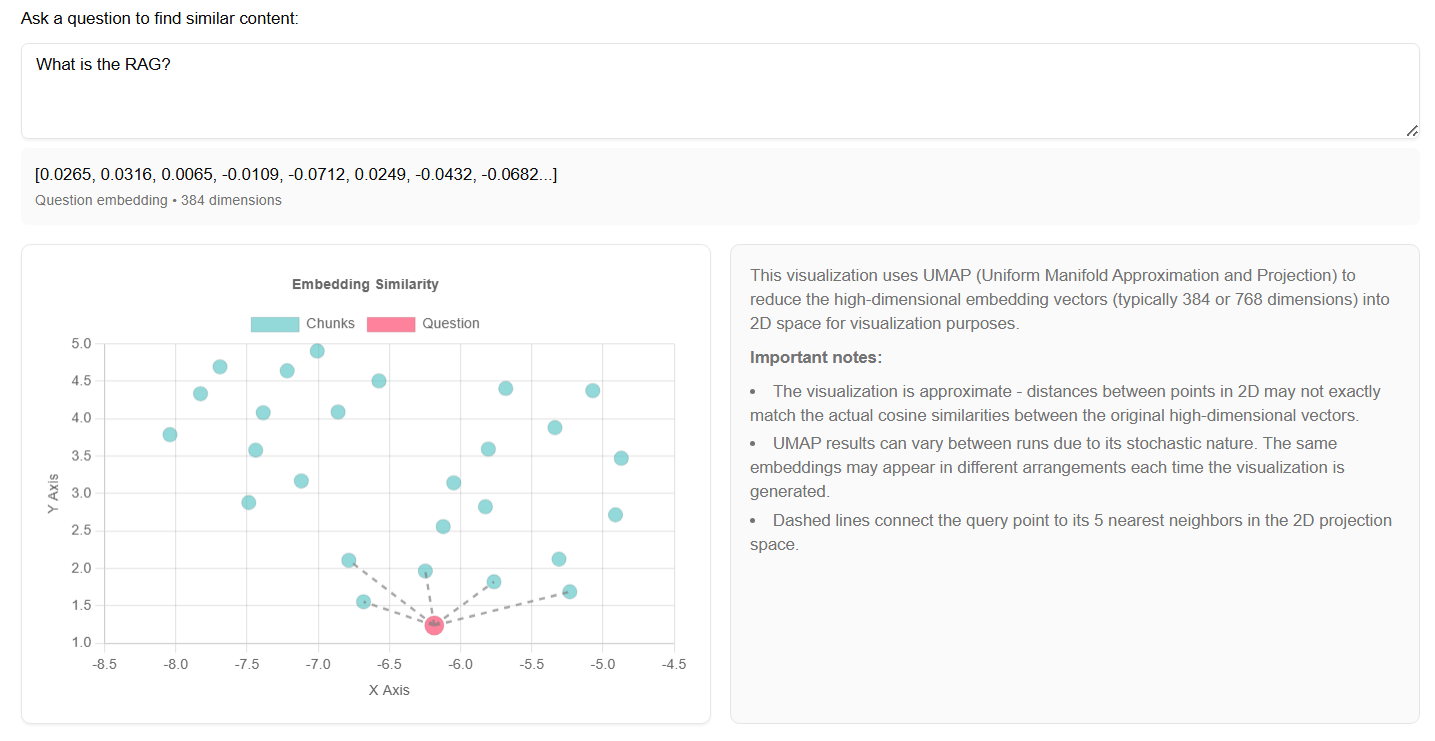 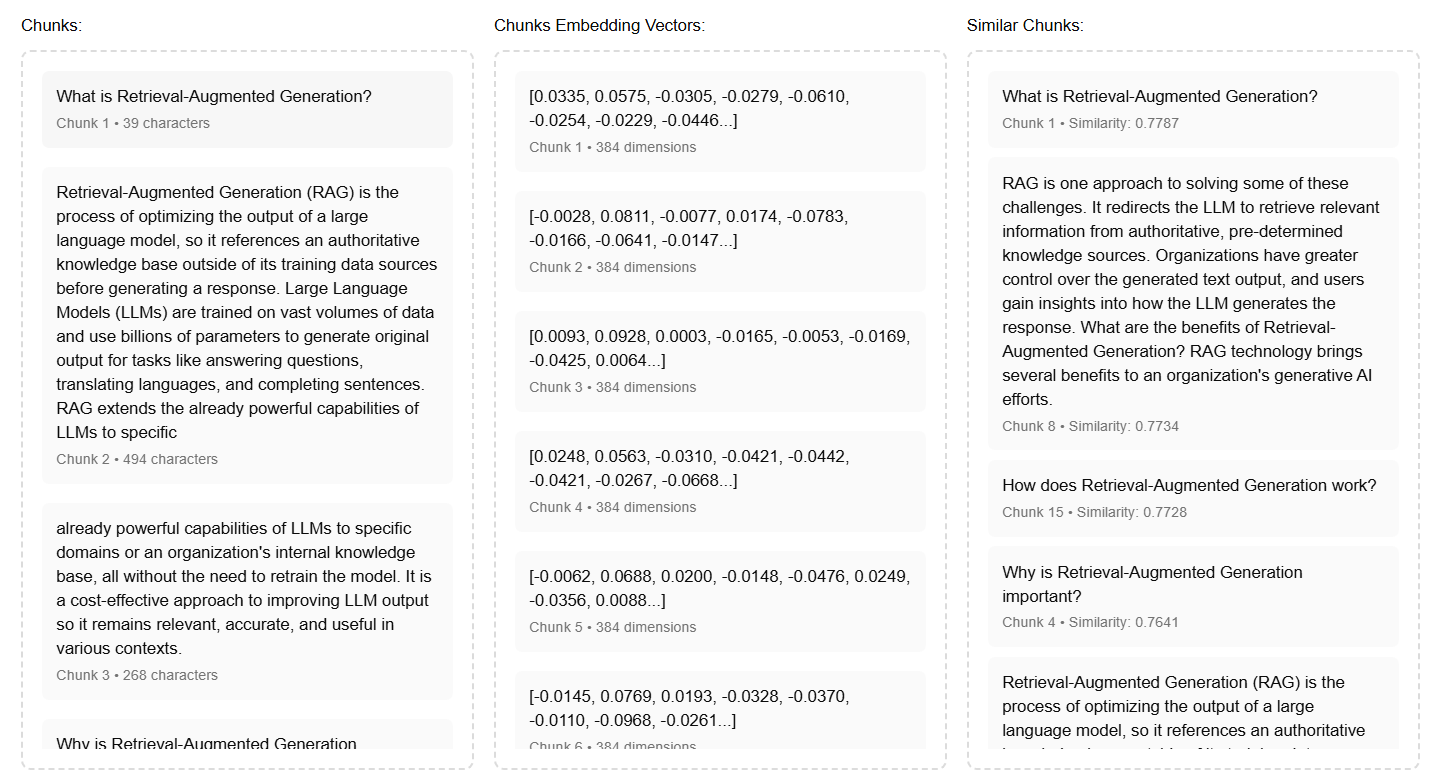 <br> <br>

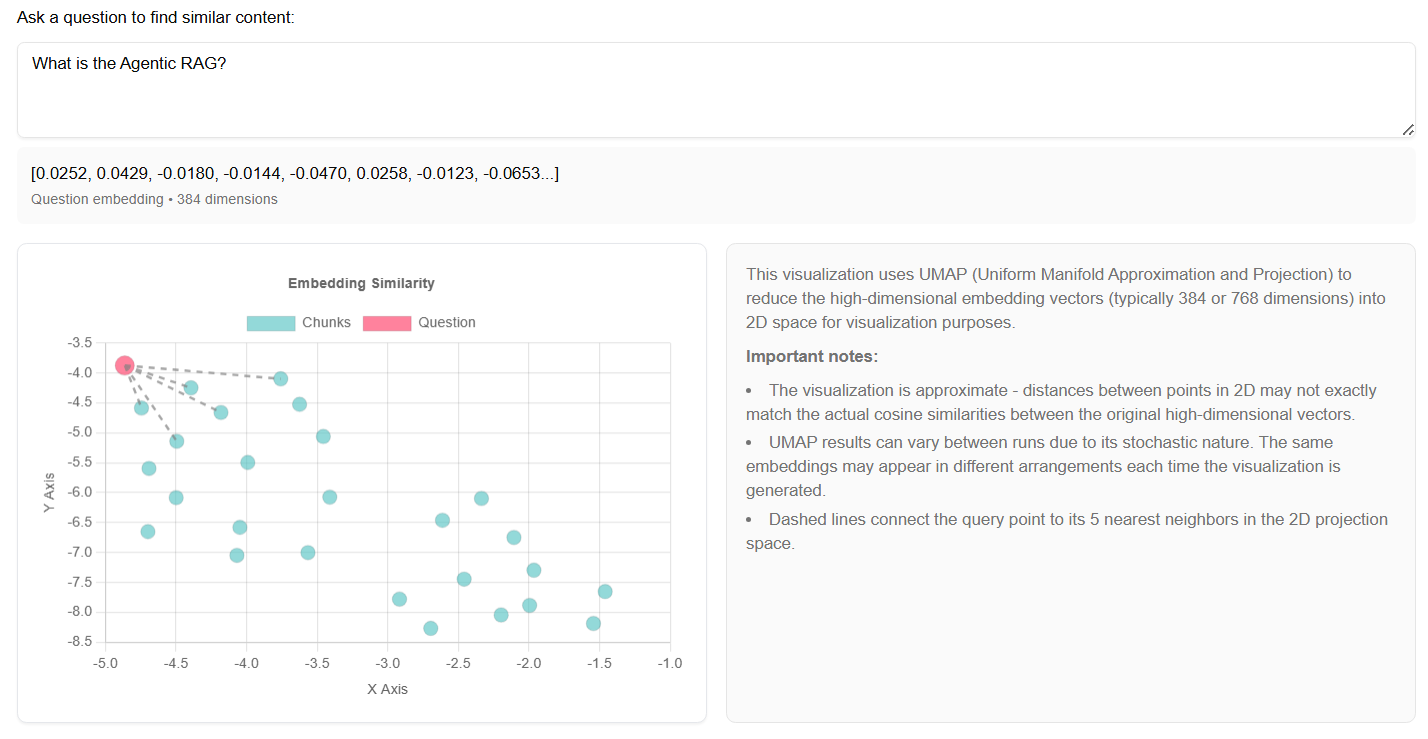 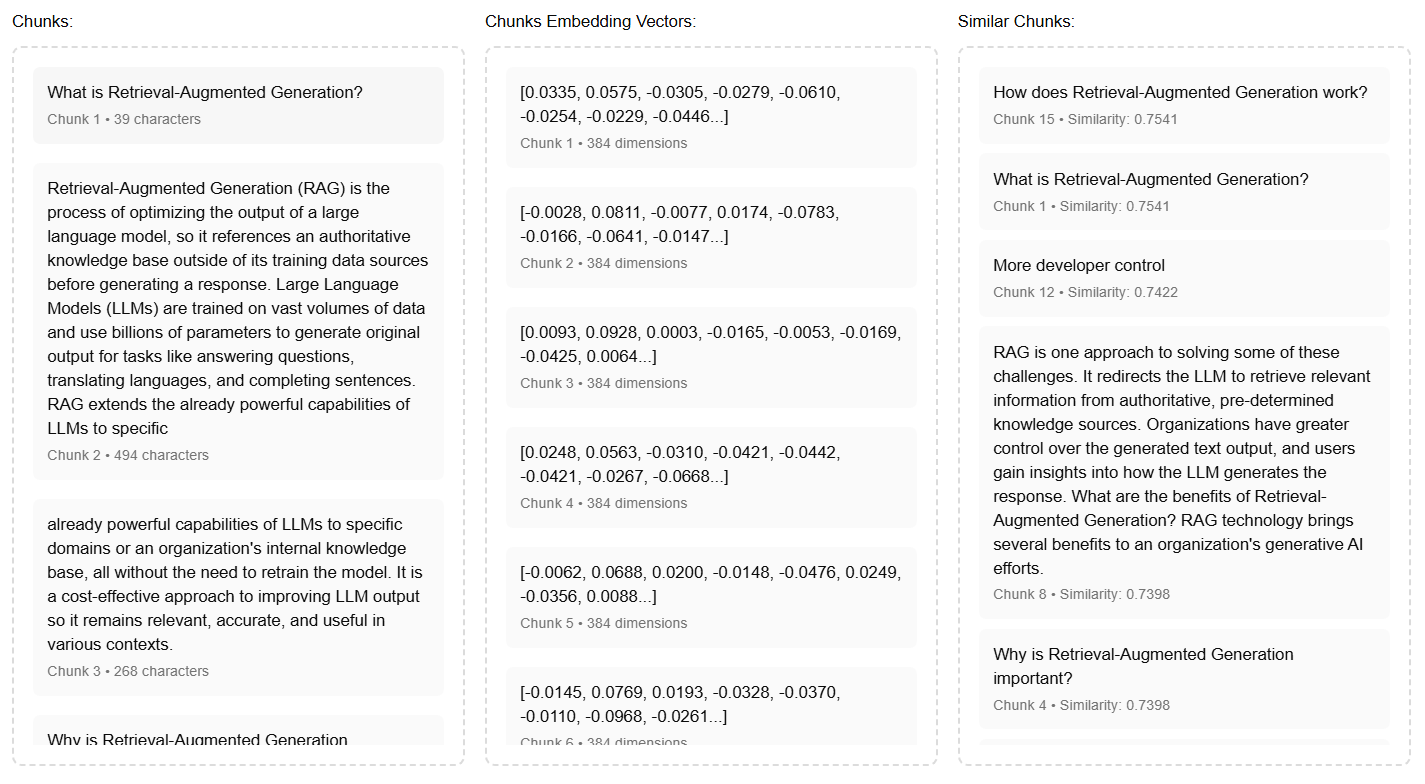 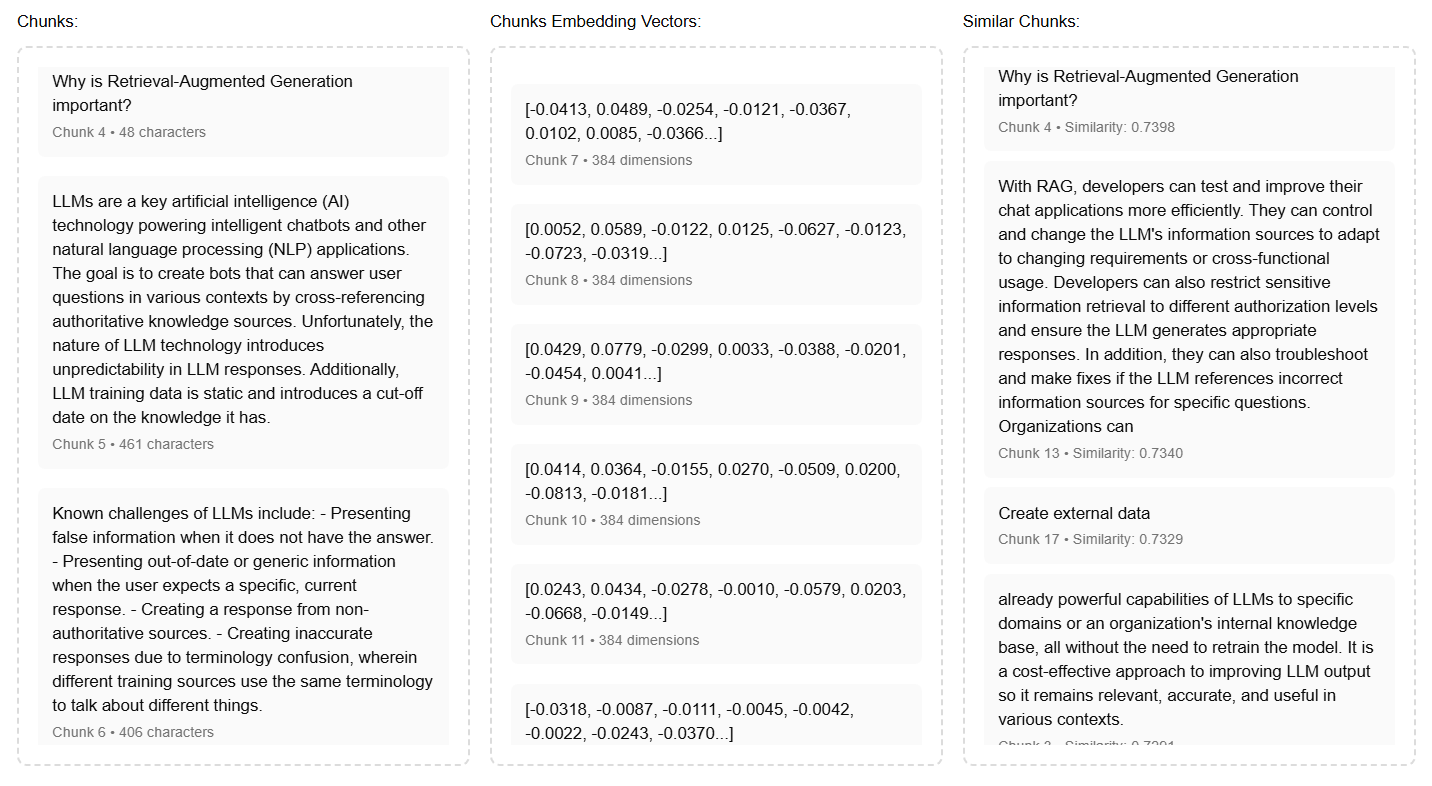
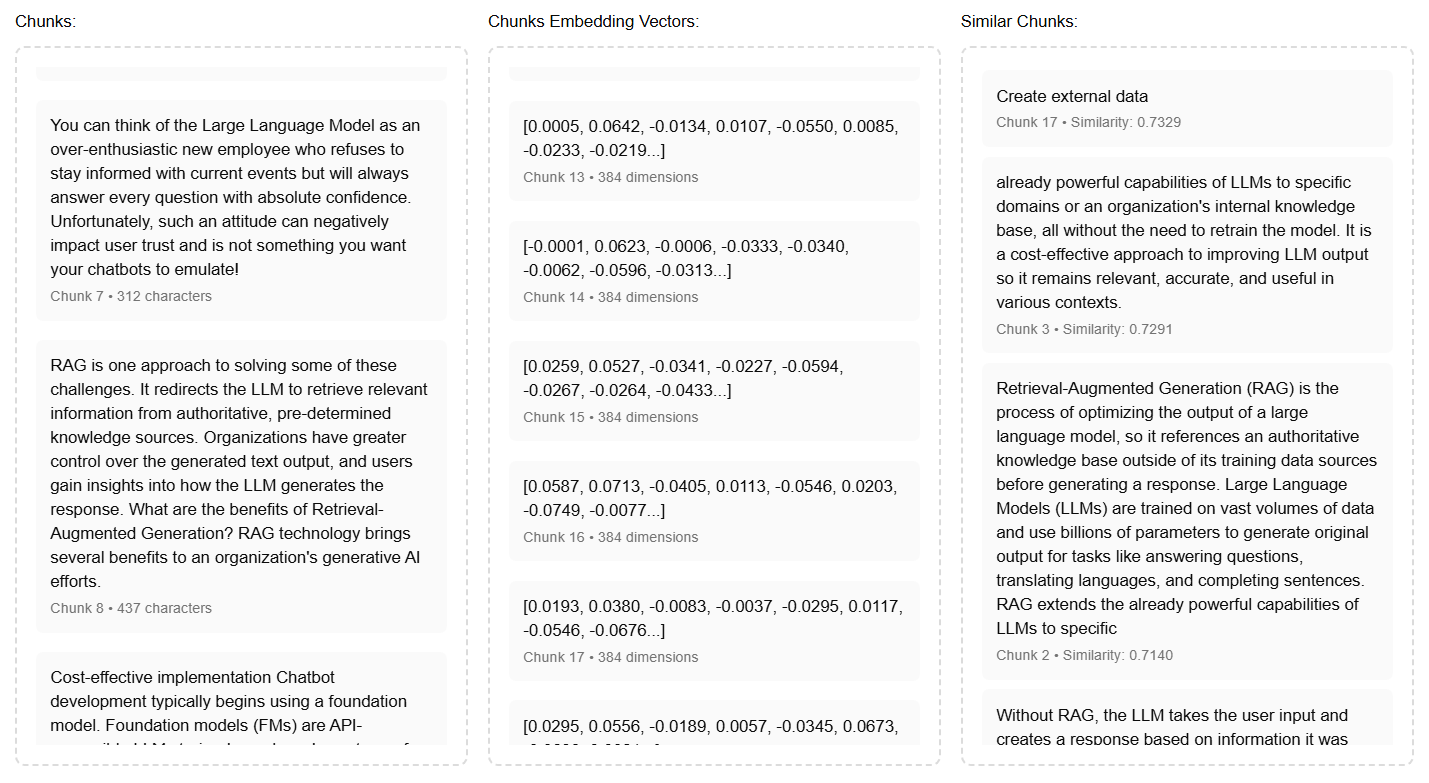 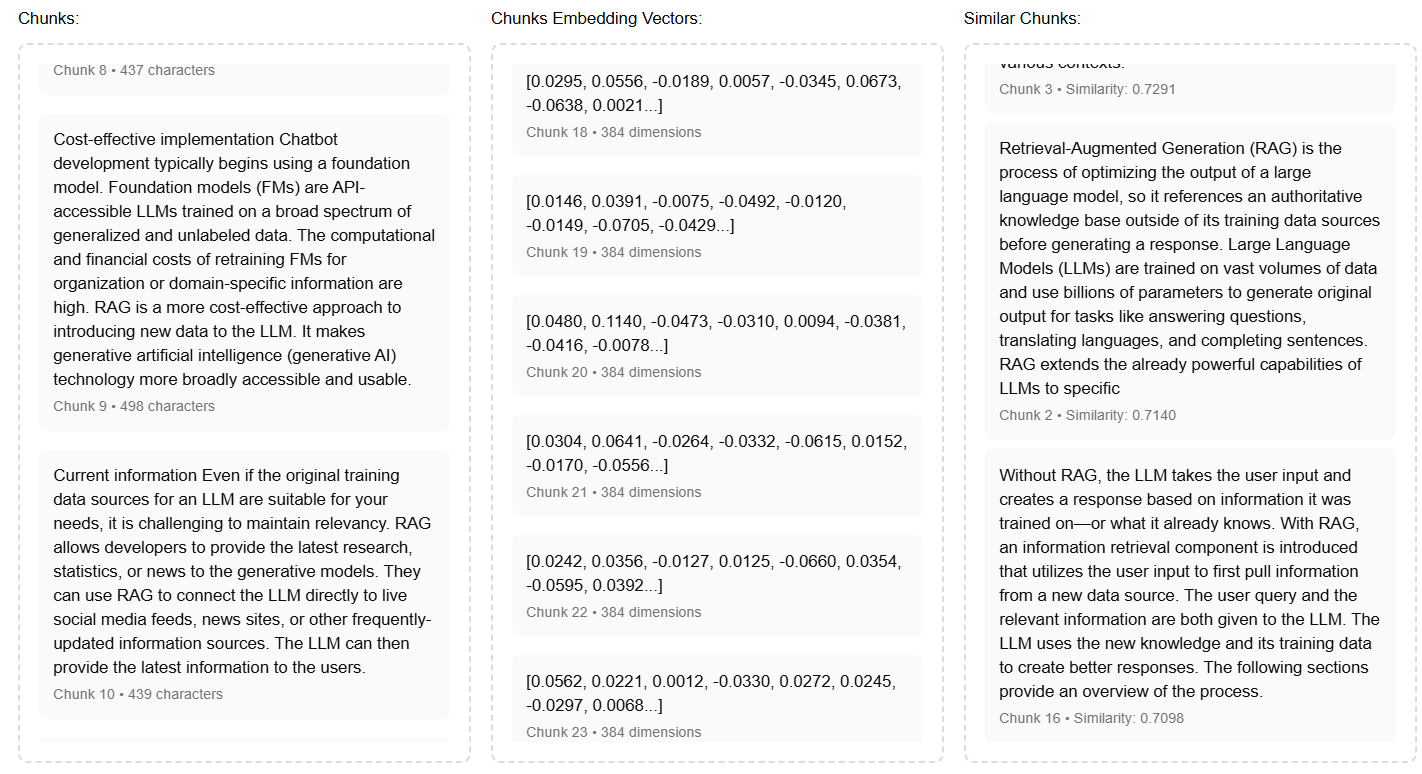 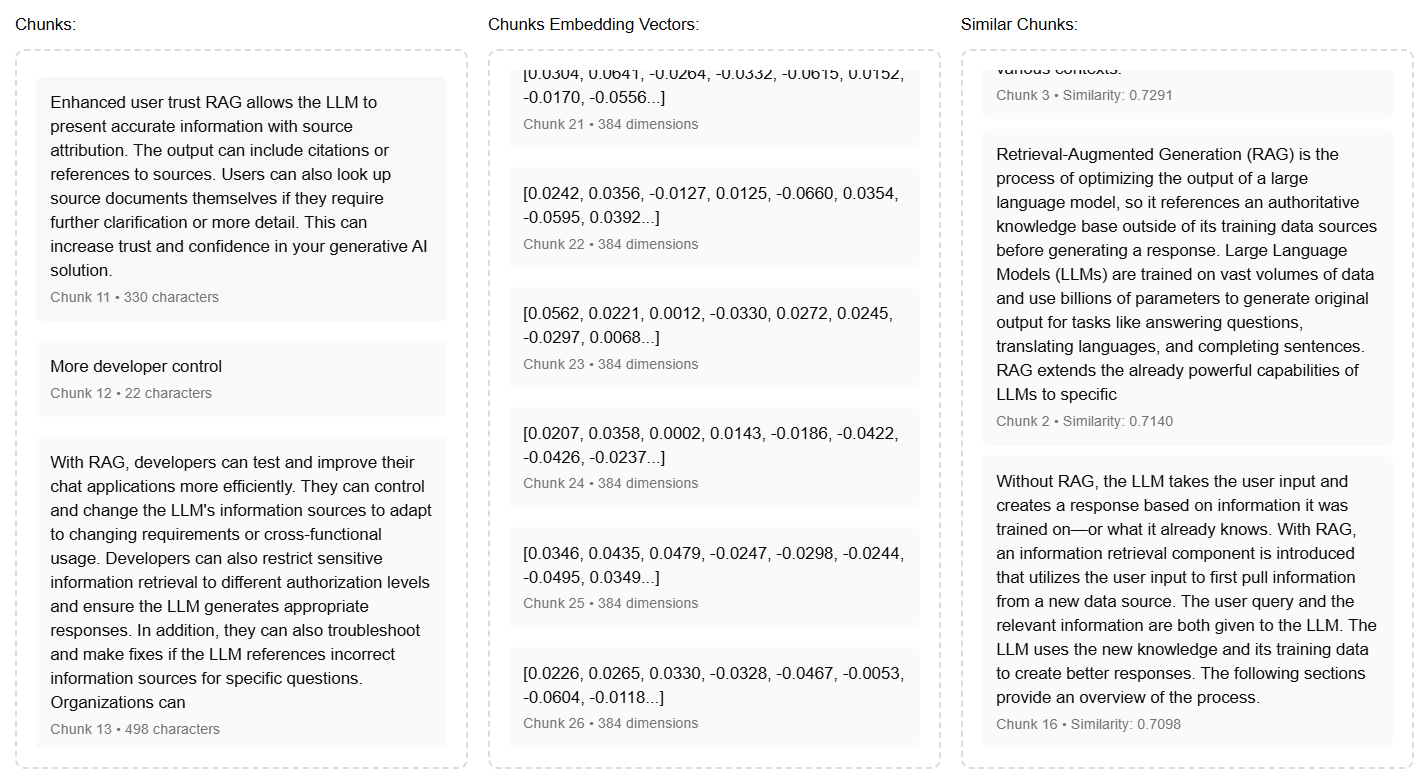
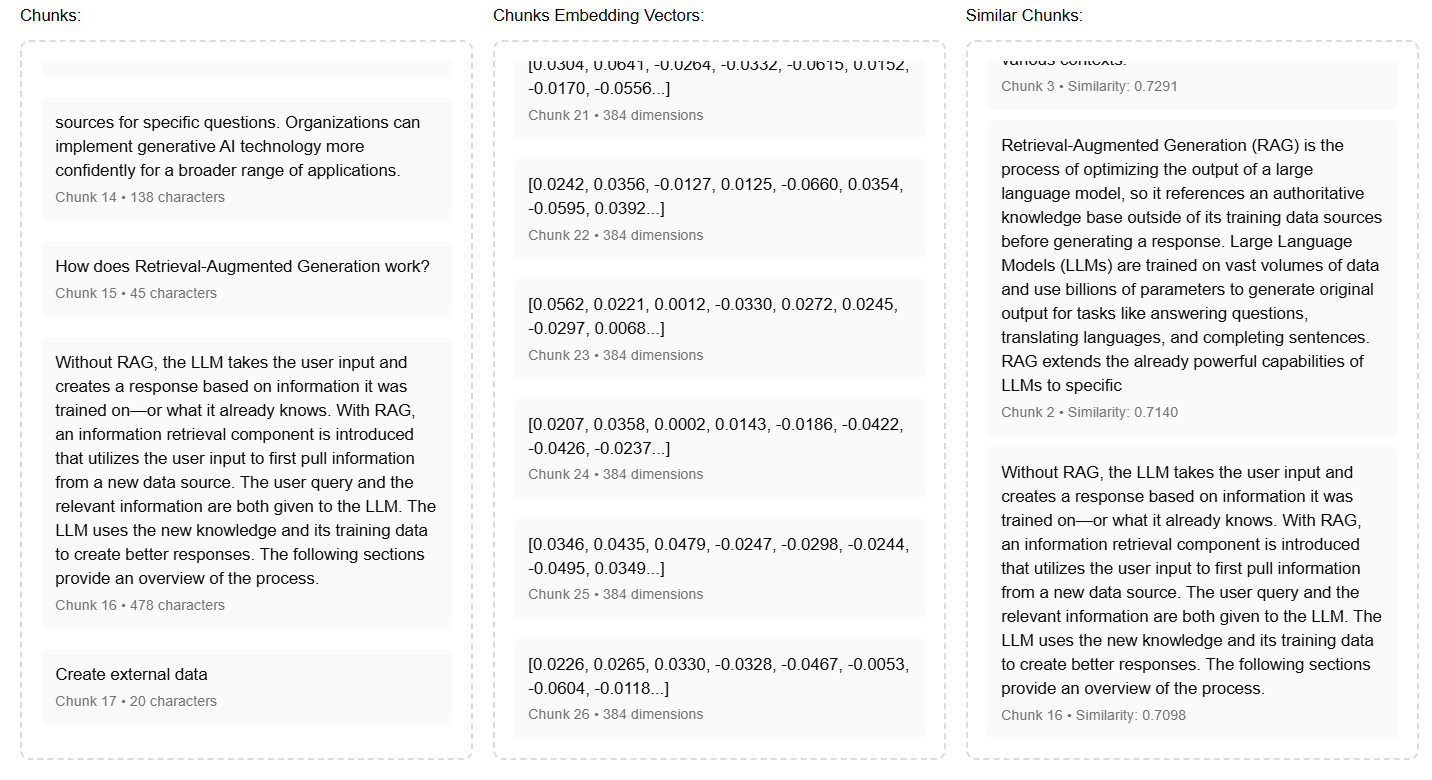 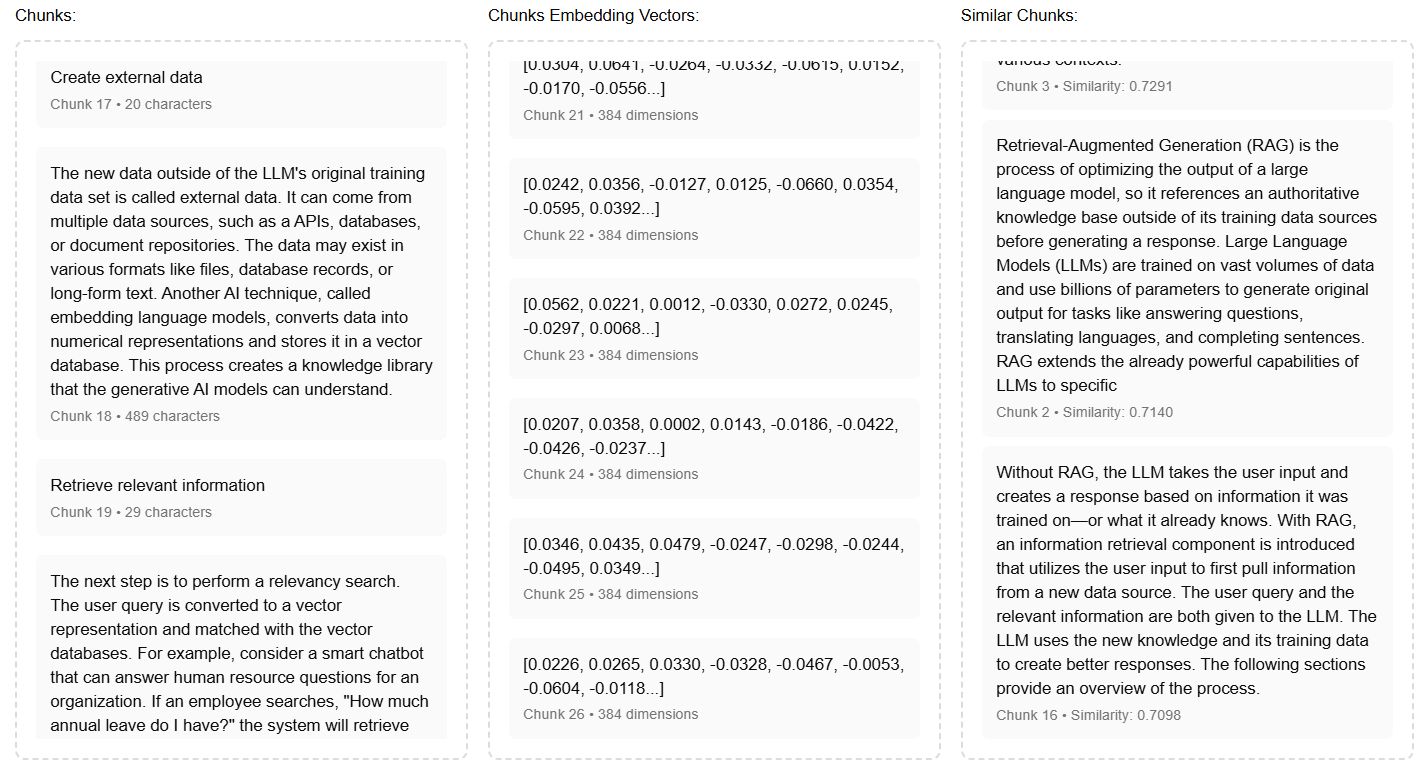 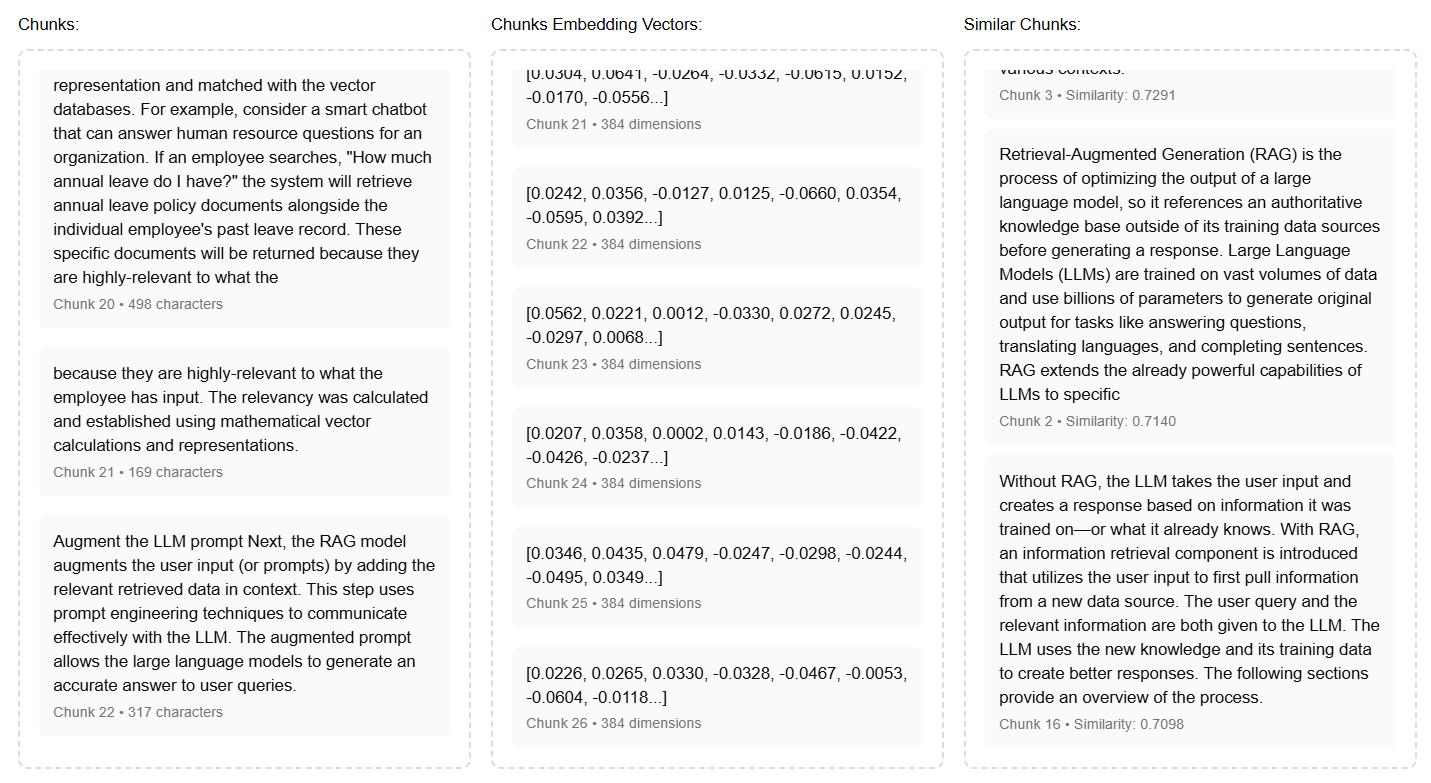
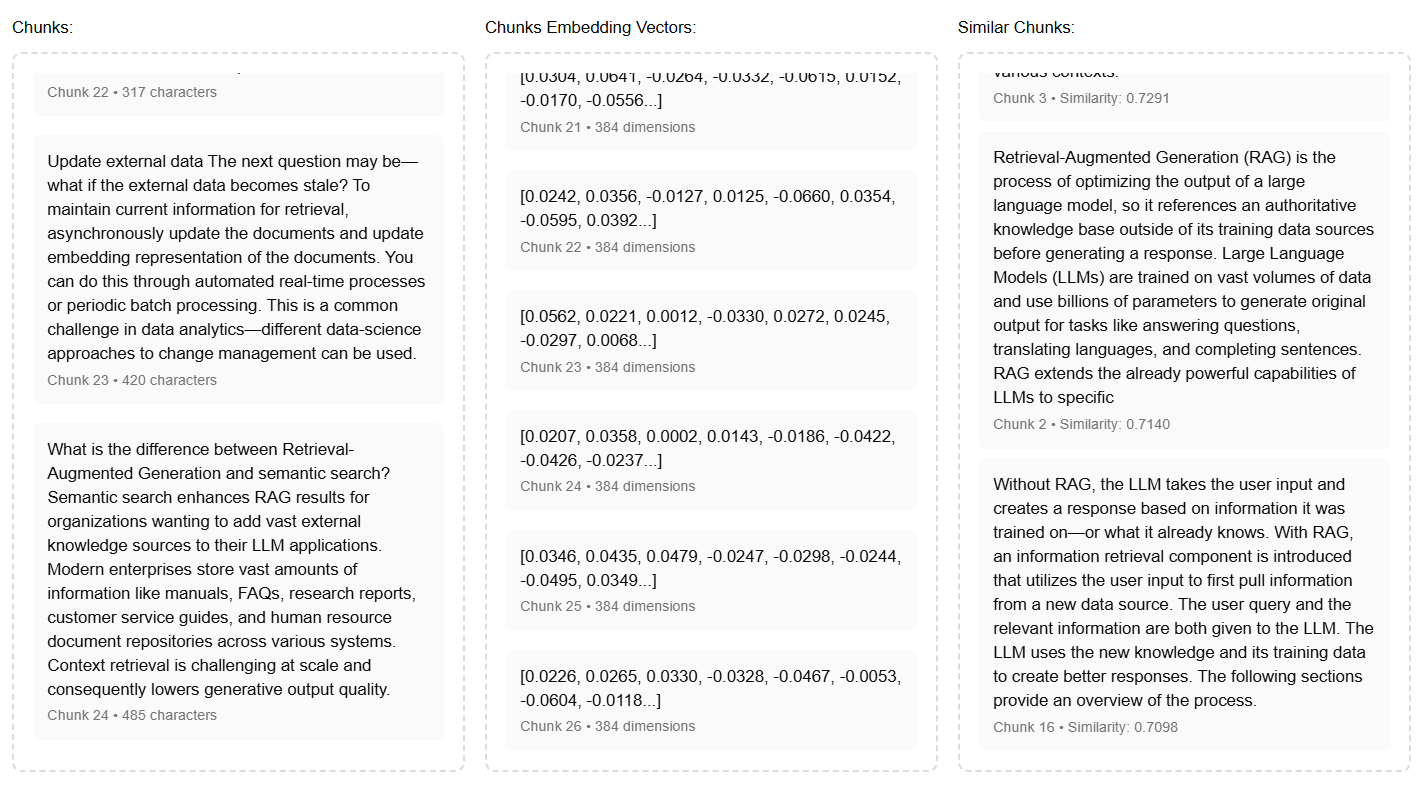 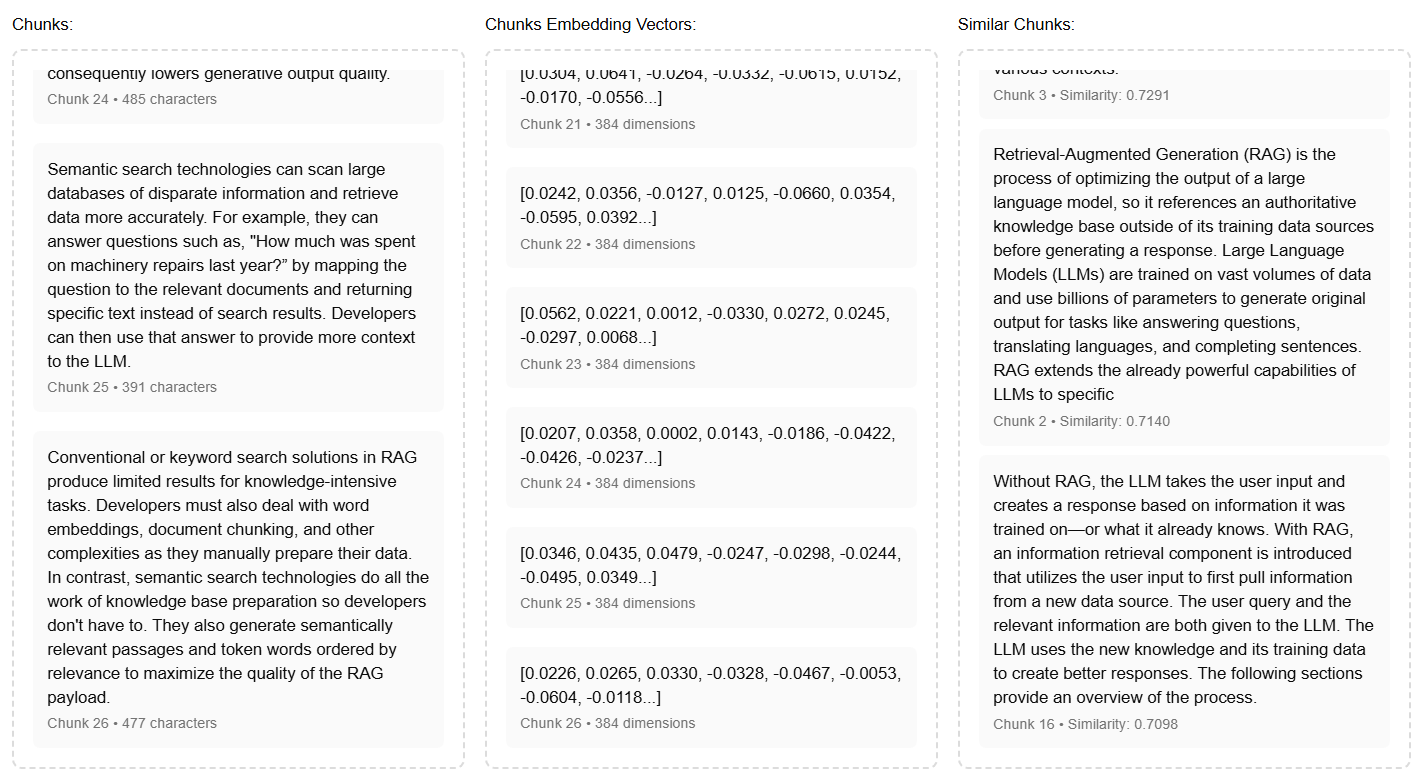 <br><br>

---

#### 3. Response Generation
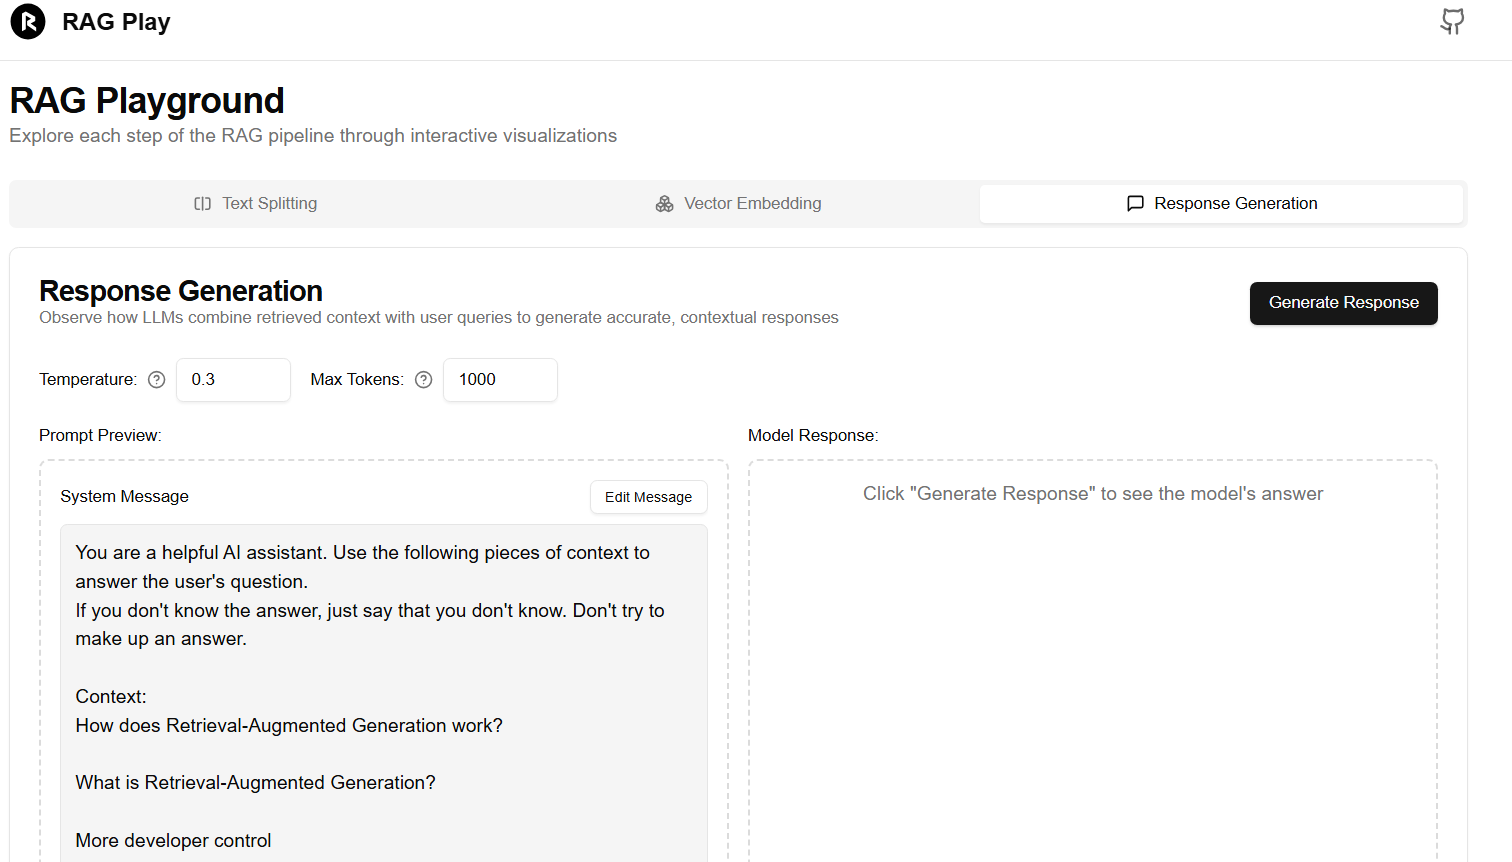 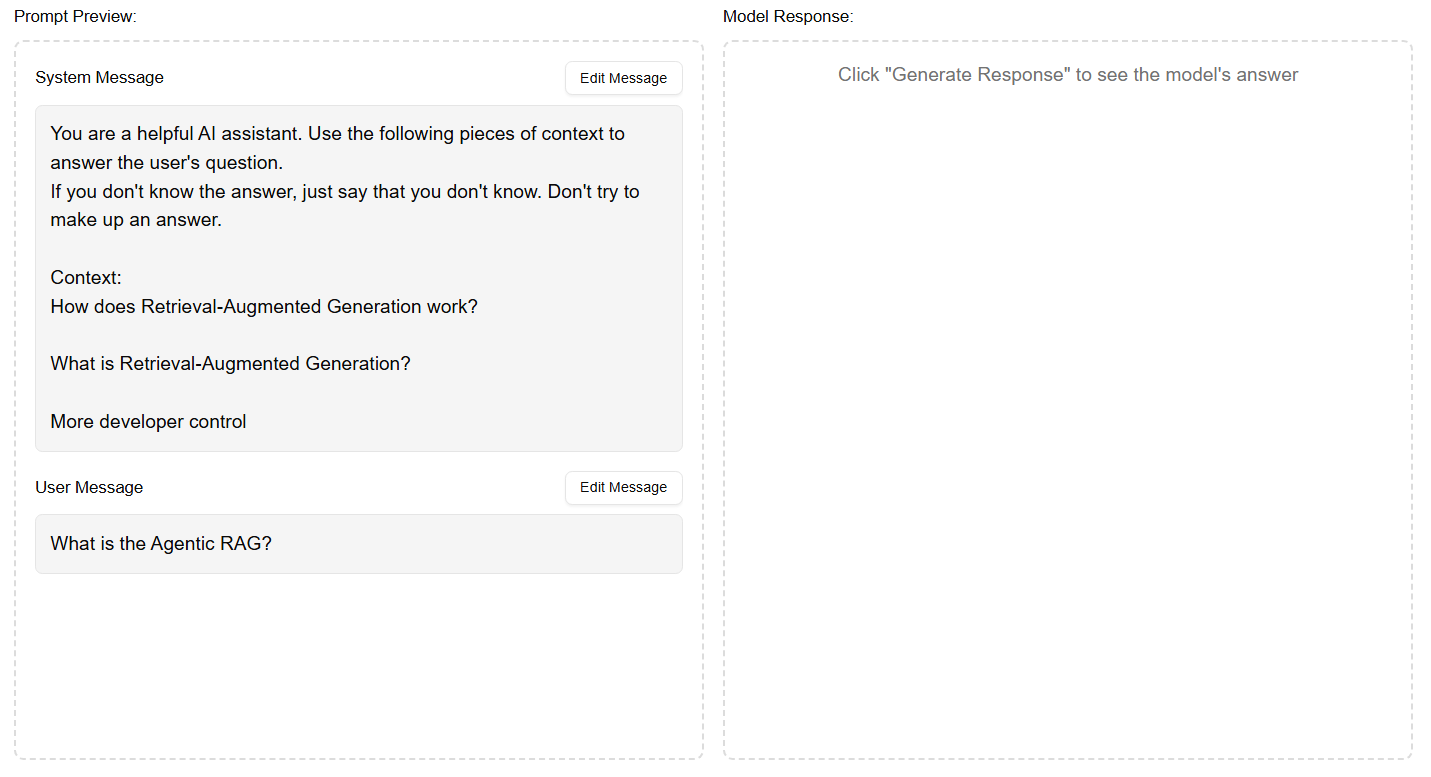 <br><br> 
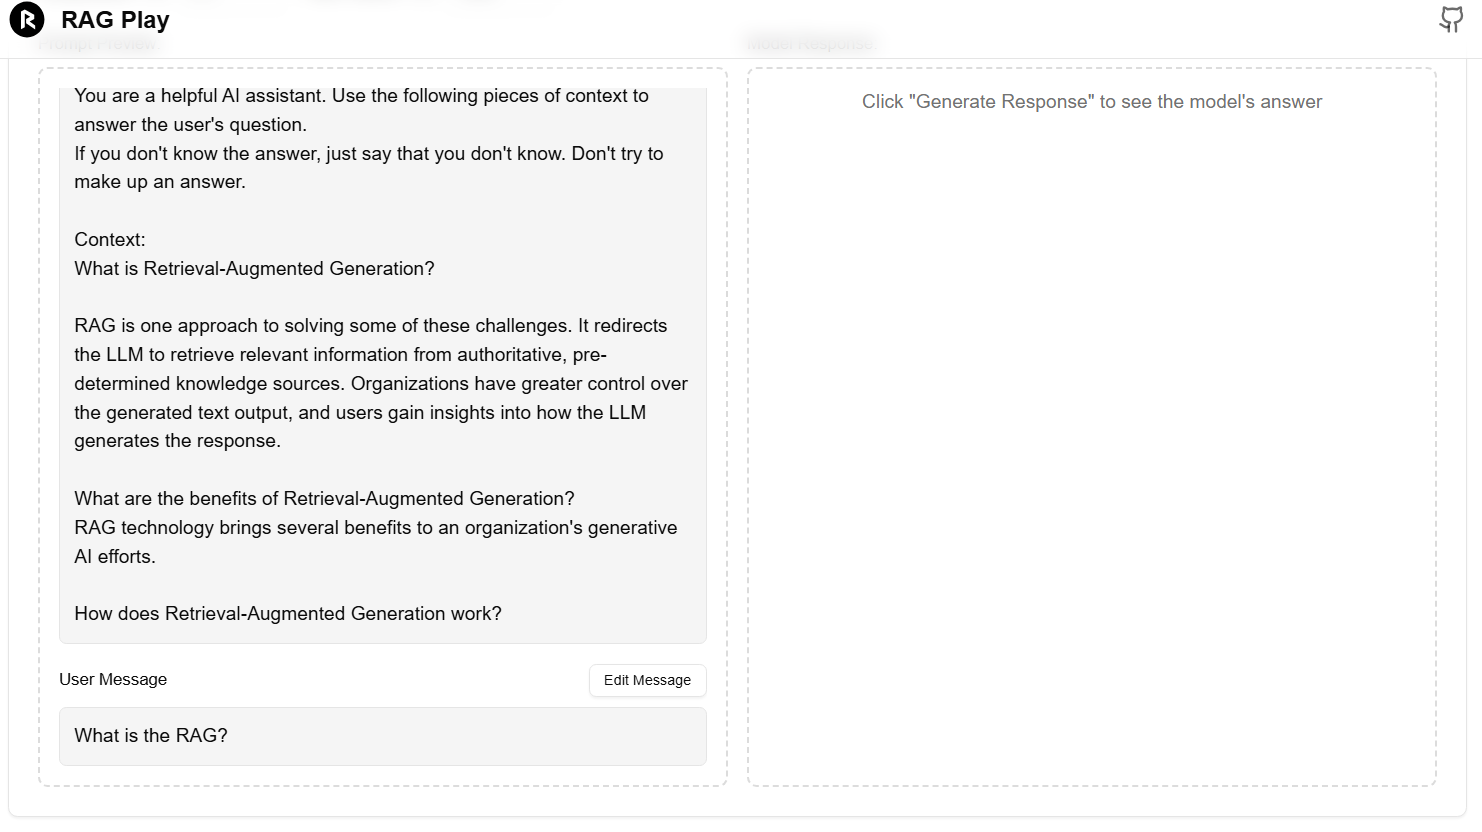 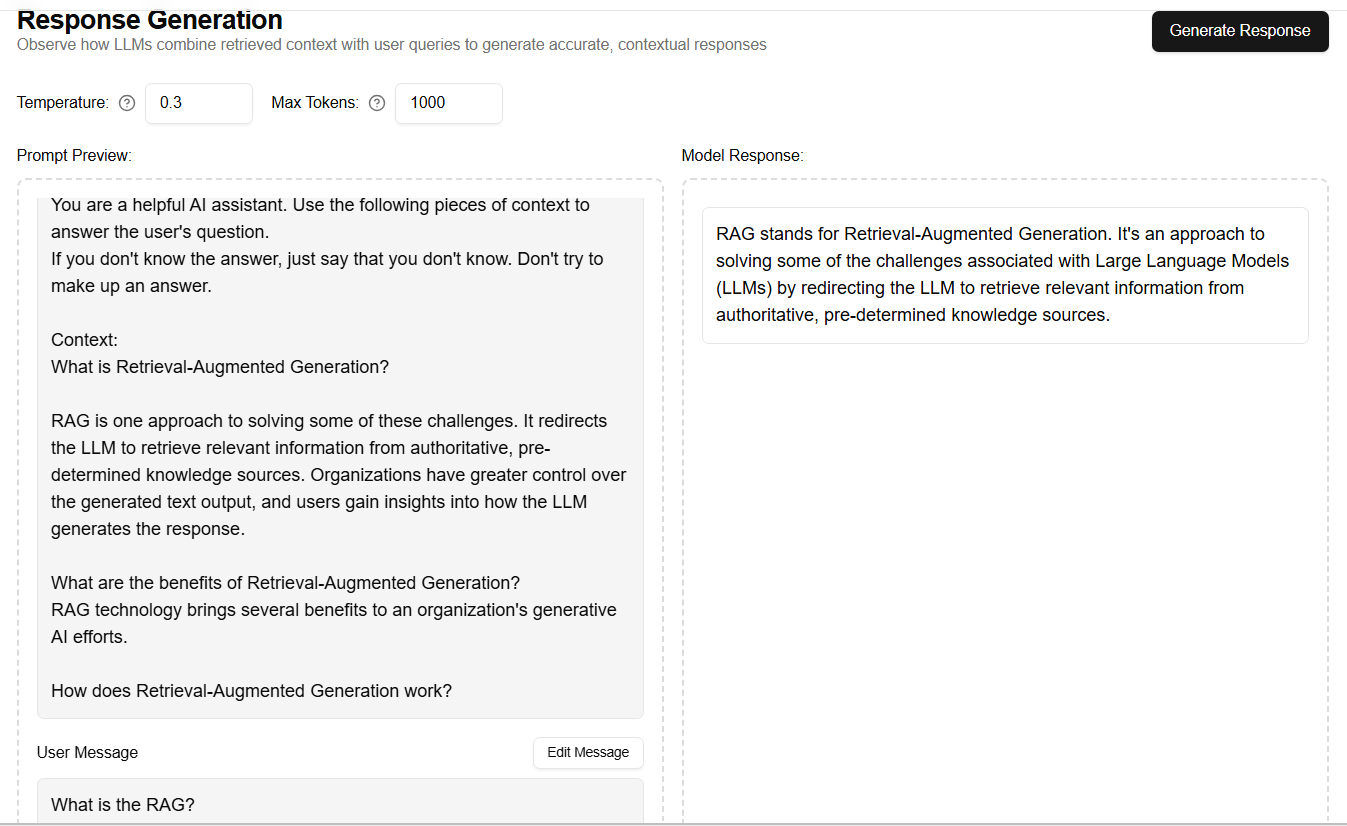

---

#### Vertex AI RAG Engine - **Example**
##### **`multi_tool_bot`**
##### **.env**
```bash
GOOGLE_GENAI_USE_VERTEXAI=TRUE

# Vertex Backend config
GOOGLE_CLOUD_PROJECT=gen-lang-client-0634579487
GOOGLE_CLOUD_LOCATION = "us-central1"
GOOGLE_CLOUD_STAGING_BUCKET = "gs://your-gcs-bucket-name"
```

----

##### **agent.py**
```Python
import datetime
from zoneinfo import ZoneInfo
from google.adk.agents import Agent
from multi_tool_bot.tools_adk_rag import get_all_corpora

def get_weather(city: str) -> dict:
    """Retrieves the current weather report for a specified city.

    Args:
        city (str): The name of the city for which to retrieve the weather report.

    Returns:
        dict: status and result or error msg.
    """
    if city.lower() == "new york":
        return {
            "status": "success",
            "report": (
                "The weather in New York is sunny with a temperature of 25 degrees"
                " Celsius (77 degrees Fahrenheit)."
            ),
        }
    else:
        return {
            "status": "error",
            "error_message": f"Weather information for '{city}' is not available.",
        }


def get_current_time(city: str) -> dict:
    """Returns the current time in a specified city.

    Args:
        city (str): The name of the city for which to retrieve the current time.

    Returns:
        dict: status and result or error msg.
    """

    if city.lower() == "new york":
        tz_identifier = "America/New_York"
    else:
        return {
            "status": "error",
            "error_message": (
                f"Sorry, I don't have timezone information for {city}."
            ),
        }

    tz = ZoneInfo(tz_identifier)
    now = datetime.datetime.now(tz)
    report = (
        f'The current time in {city} is {now.strftime("%Y-%m-%d %H:%M:%S %Z%z")}'
    )
    return {"status": "success", "report": report}


root_agent = Agent(
    name='multi_tool_bot',
    model='gemini-2.0-flash',
    description='An agent that can use multiple tools to answer user queries.',
    instruction='You are a helpful assistant that can use multiple tools to answer user queries.',
    tools=[get_weather,get_current_time,get_all_corpora]
)
```
---

##### **tools_adk_rag.py**
```Python
import os
from dotenv import load_dotenv
import vertexai
from vertexai import rag

load_dotenv()

# Constants
PROJECT_ID = "gen-lang-client-0634579487"
LOCATION = "us-east4"
DISPLAY_NAME = "atgaga" # Corpus Display Name
PATH = [
    # TODO: Add your Actual GCG or Google Drive Path here
    "gs:/rag-data-adk/1706.03762v7.pdf"
]

def get_all_corpora() -> dict:
    """Retrieves all existing RAG corpora from Vertex AI.

    Returns:
        dict: A structured dictionary containing the list of all RAG corpora,
              or an error message if retrieval fails.
    """
    try:
        # Ensure Vertex AI is initialized
        vertexai.init(project=PROJECT_ID, location=LOCATION)

        # List all corpora
        corpora = list(rag.list_corpora())

        if not corpora:
            return {
                "status": "success",
                "message": "No RAG corpora found in the project.",
                "corpora": [],
            }

        # Build structured corpus info
        corpus_list = []
        for corpus in corpora:
            corpus_list.append({
                "name": corpus.name,
                "display_name": corpus.display_name,
                "create_time": str(corpus.create_time),
                "update_time": str(corpus.update_time),
                "description": getattr(corpus, "description", None),
            })

        return {
            "status": "success",
            "total_corpora": len(corpus_list),
            "corpora": corpus_list,
        }

    except Exception as e:
        return {
            "status": "error",
            "error_message": f"Failed to list RAG corpora: {str(e)}",
        }
```

---

##### **rag_tool**
```Python
import os
import vertexai
from vertexai import rag
from dotenv import load_dotenv

load_dotenv()

PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT")
LOCATION = "us-east4"

DEFAULT_CHUNK_SIZE = 512
DEFAULT_CHUNK_OVERLAP = 100
DEFAULT_TOP = 3
DEFAULT_DISTANCE_THRESHOLD = 0.5
DEFAULT_EMBEDDING_MODEL = "publishers/google/model/text-embedding-002"
DEFAULT_EMBEDDING_REQUESTS_PER_MIN = 1000

vertexai.init(project=PROJECT_ID, location=LOCATION)

print(rag.get_corpus("atgaga")) # "atgaga" corpus created in my google cloud
```
----

##### **rag_tool_enhanced.py**
```Python
import os
from dotenv import load_dotenv
import vertexai
from vertexai import rag
from vertexai.generative_models import GenerativeModel, Tool

# Constants
PROJECT_ID = "gen-lang-client-0634579487"
LOCATION = "us-east4"
DISPLAY_NAME = "atgaga" # Corpus Display Name
PATH = [
    # TODO: Add your Actual GCG or Google Drive Path here
    "gs:/rag-data-adk/1706.03762v7.pdf"
]

# Initialize Vertex AI 
vertexai.init(project=PROJECT_ID, location=LOCATION)


# =========================================================
# 🔹 Function: Create or Get an Existing RAG Corpus
# =========================================================
def create_or_get_corpus(name: str):
    """Creates a new RAG corpus if not found, else reuses the existing one."""
    existing_corpora = list(rag.list_corpora())
    for corpus in existing_corpora:
        if corpus.display_name == name:
            print(f"🔁 Reusing existing RAG corpus: {corpus.name}")
            return corpus

    print(f"🆕 Creating new RAG corpus: {name}")
    embedding_model_config = rag.RagEmbeddingModelConfig(
        vertex_prediction_endpoint=rag.VertexPredictionEndpoint(
            publisher_model="publishers/google/models/text-embedding-005"
        )
    )

    new_corpus = rag.create_corpus(
        display_name=name,
        backend_config=rag.RagVectorDbConfig(
            rag_embedding_model_config=embedding_model_config
        ),
    )
    print(f"✅ Created new RAG corpus: {new_corpus.name}")
    return new_corpus


# =========================================================
# 🔹 Main Execution
# =========================================================
def main():
    # Load environment variables
    load_dotenv()

    PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT")
    LOCATION = "us-east4"
    NAME = "atgaga"

    # Initialize Vertex AI
    vertexai.init(project=PROJECT_ID, location=LOCATION)

    # === Create or Get RAG Corpus ===
    rag_corpus = create_or_get_corpus(NAME)

    # === Import Files (only if empty) ===
    rag_files = list(rag.list_files(rag_corpus.name))
    if not rag_files:
        print("📁 Importing new files into RAG corpus...")
        paths = [
            "gs://your_bucket/sample.pdf",  # Replace with your file path
        ]
        rag.import_files(
            rag_corpus.name,
            paths,
            transformation_config=rag.TransformationConfig(
                chunking_config=rag.ChunkingConfig(
                    chunk_size=512,
                    chunk_overlap=100,
                ),
            ),
            max_embedding_requests_per_min=1000,
        )
        print("✅ Files imported successfully.")
    else:
        print(f"📚 Corpus already contains {len(rag_files)} files — skipping import.")

    # === Retrieval Configuration ===
    rag_retrieval_config = rag.RagRetrievalConfig(
        top_k=3,
        filter=rag.Filter(vector_distance_threshold=0.5),
    )

    # === Direct Context Retrieval ===
    retrieval_response = rag.retrieval_query(
        rag_resources=[
            rag.RagResource(
                rag_corpus=rag_corpus.name,
            )
        ],
        text="What is RAG and why it is helpful?",
        rag_retrieval_config=rag_retrieval_config,
    )

    print("\n🔍 Direct Retrieval Response:")
    print(retrieval_response)

    # === Create a Retrieval Tool for Gemini ===
    rag_retrieval_tool = Tool.from_retrieval(
        retrieval=rag.Retrieval(
            source=rag.VertexRagStore(
                rag_resources=[
                    rag.RagResource(
                        rag_corpus=rag_corpus.name,
                    )
                ],
                rag_retrieval_config=rag_retrieval_config,
            ),
        )
    )

    # === Initialize Gemini Model ===
    rag_model = GenerativeModel(
        model_name="gemini-2.0-flash-001",
        tools=[rag_retrieval_tool],
    )

    # === Generate RAG-Augmented Response ===
    gen_response = rag_model.generate_content("What is RAG and why it is helpful?")
    print("\n🧠 Generated Response from Gemini + RAG:")
    print(gen_response.text)


# =========================================================
# 🔹 Entry Point
# =========================================================
if __name__ == "__main__":
    main()
```

---
##### `adk run multi_tool_bot`
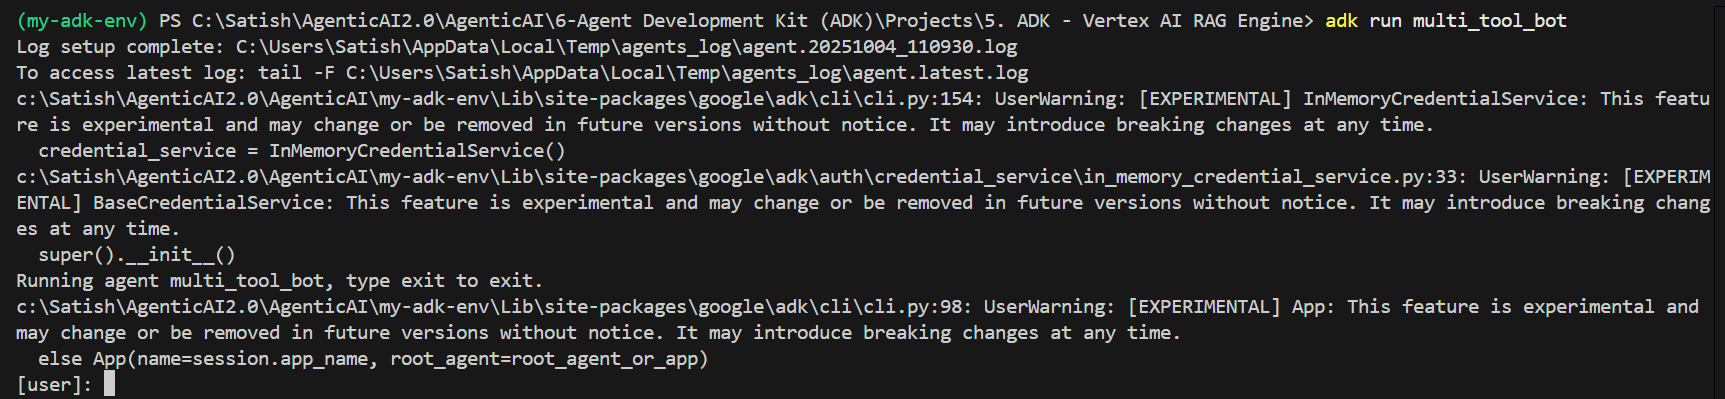 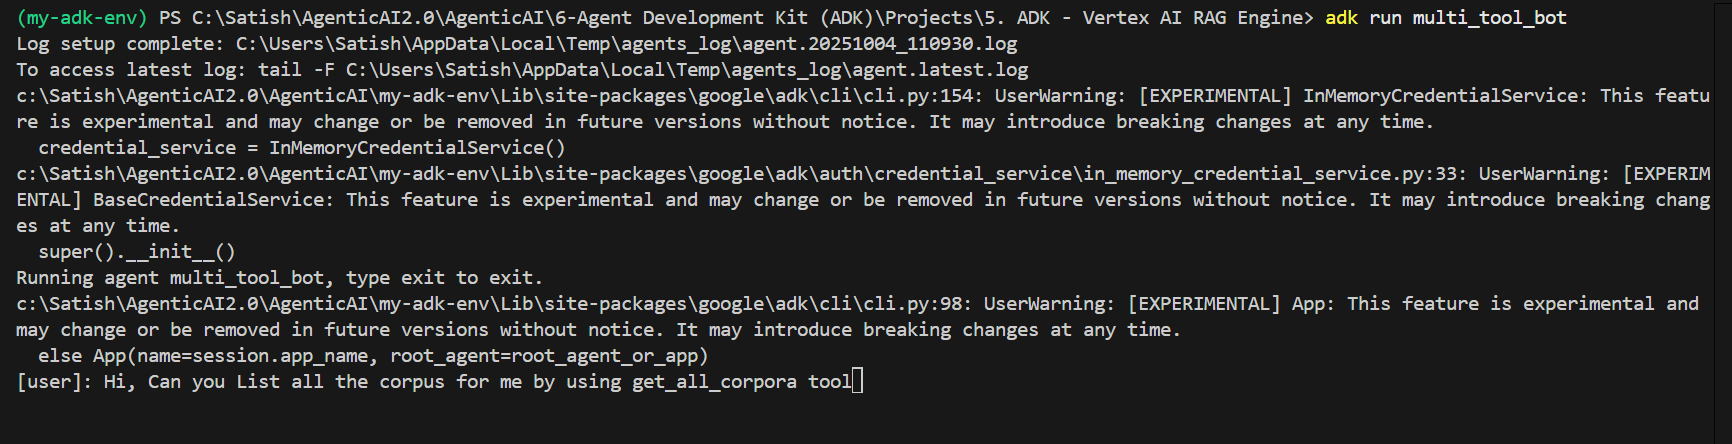 <br>
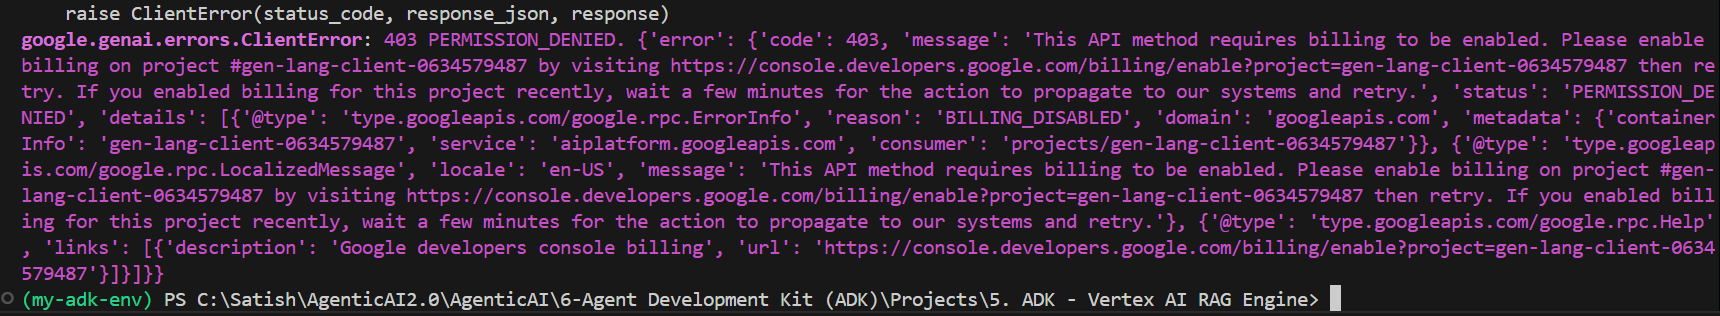

---
##### `adk web`
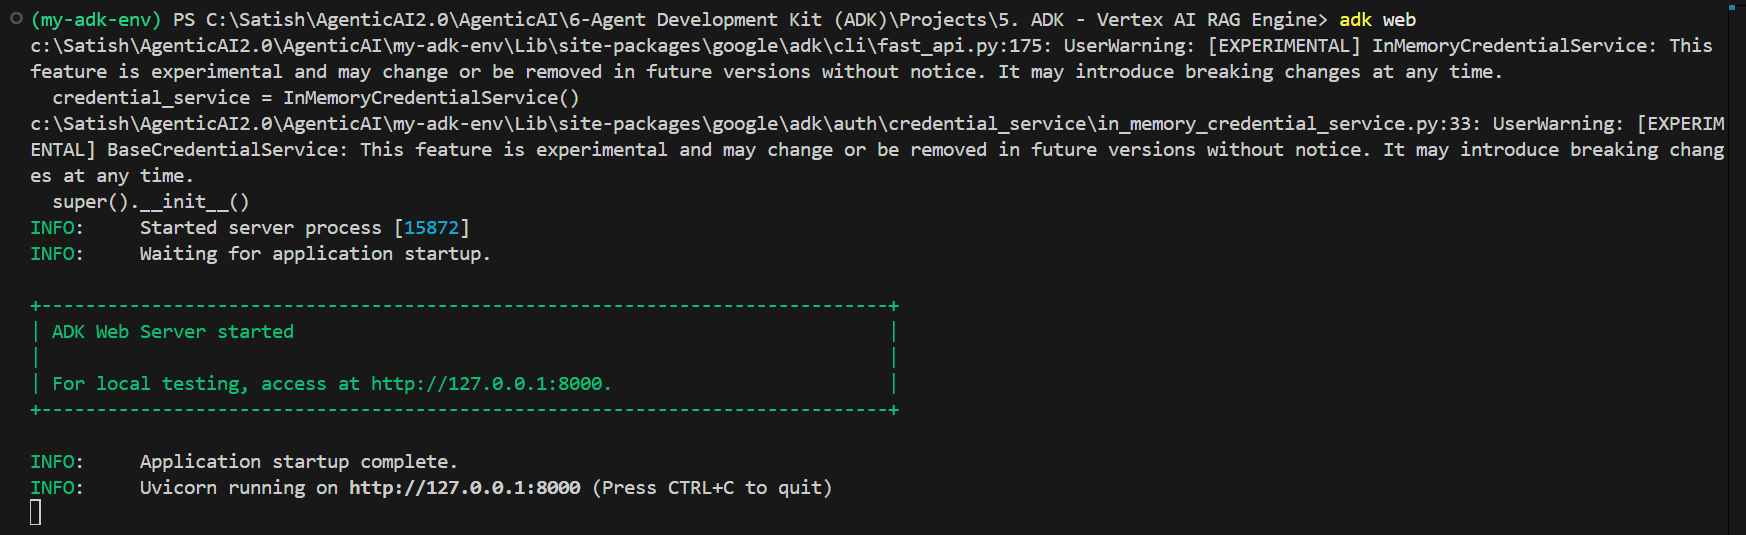 <br> 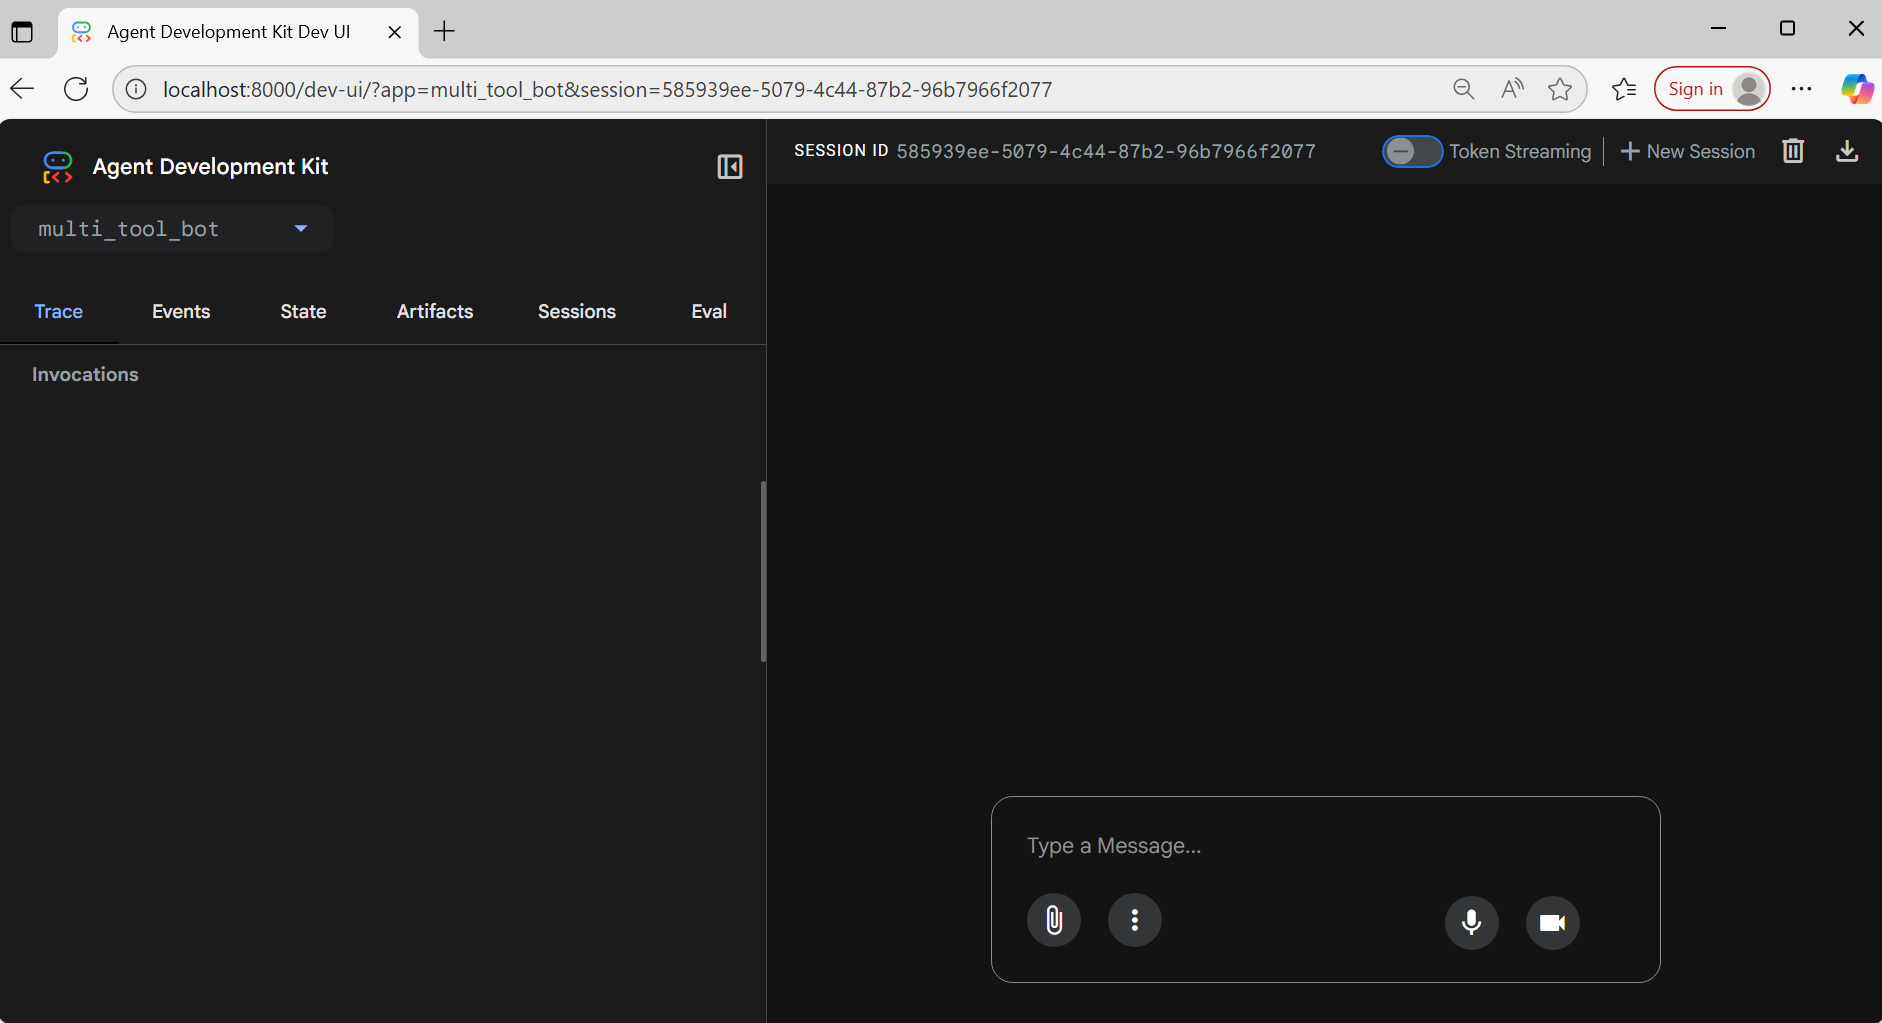
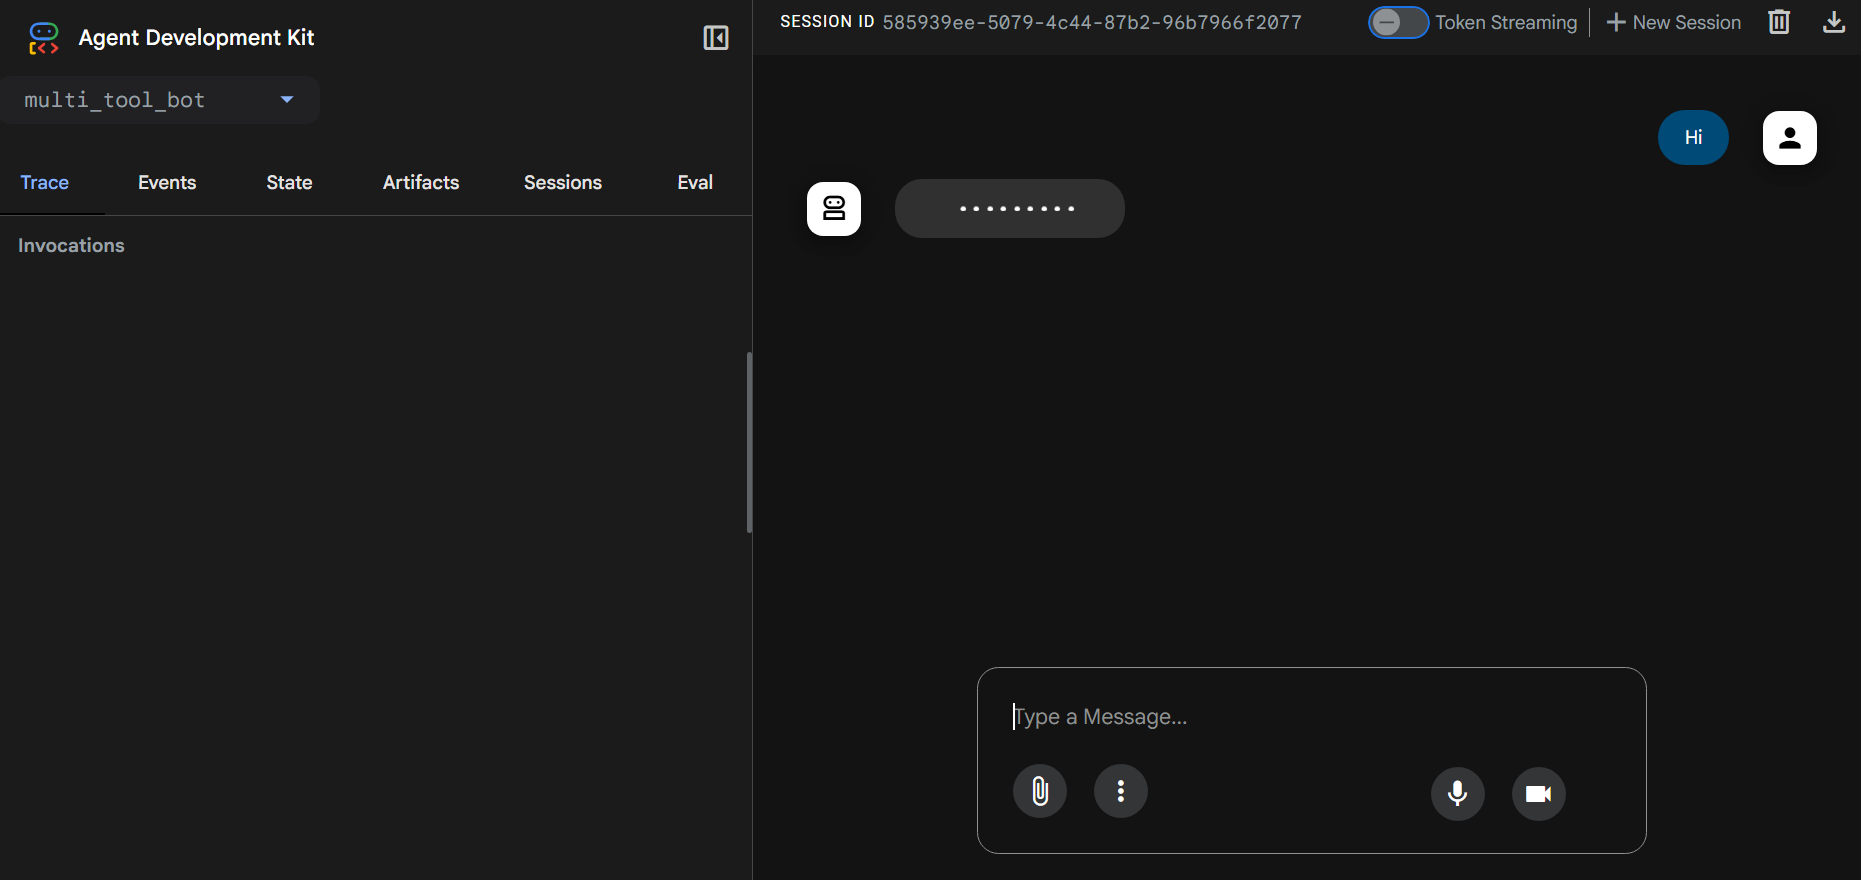 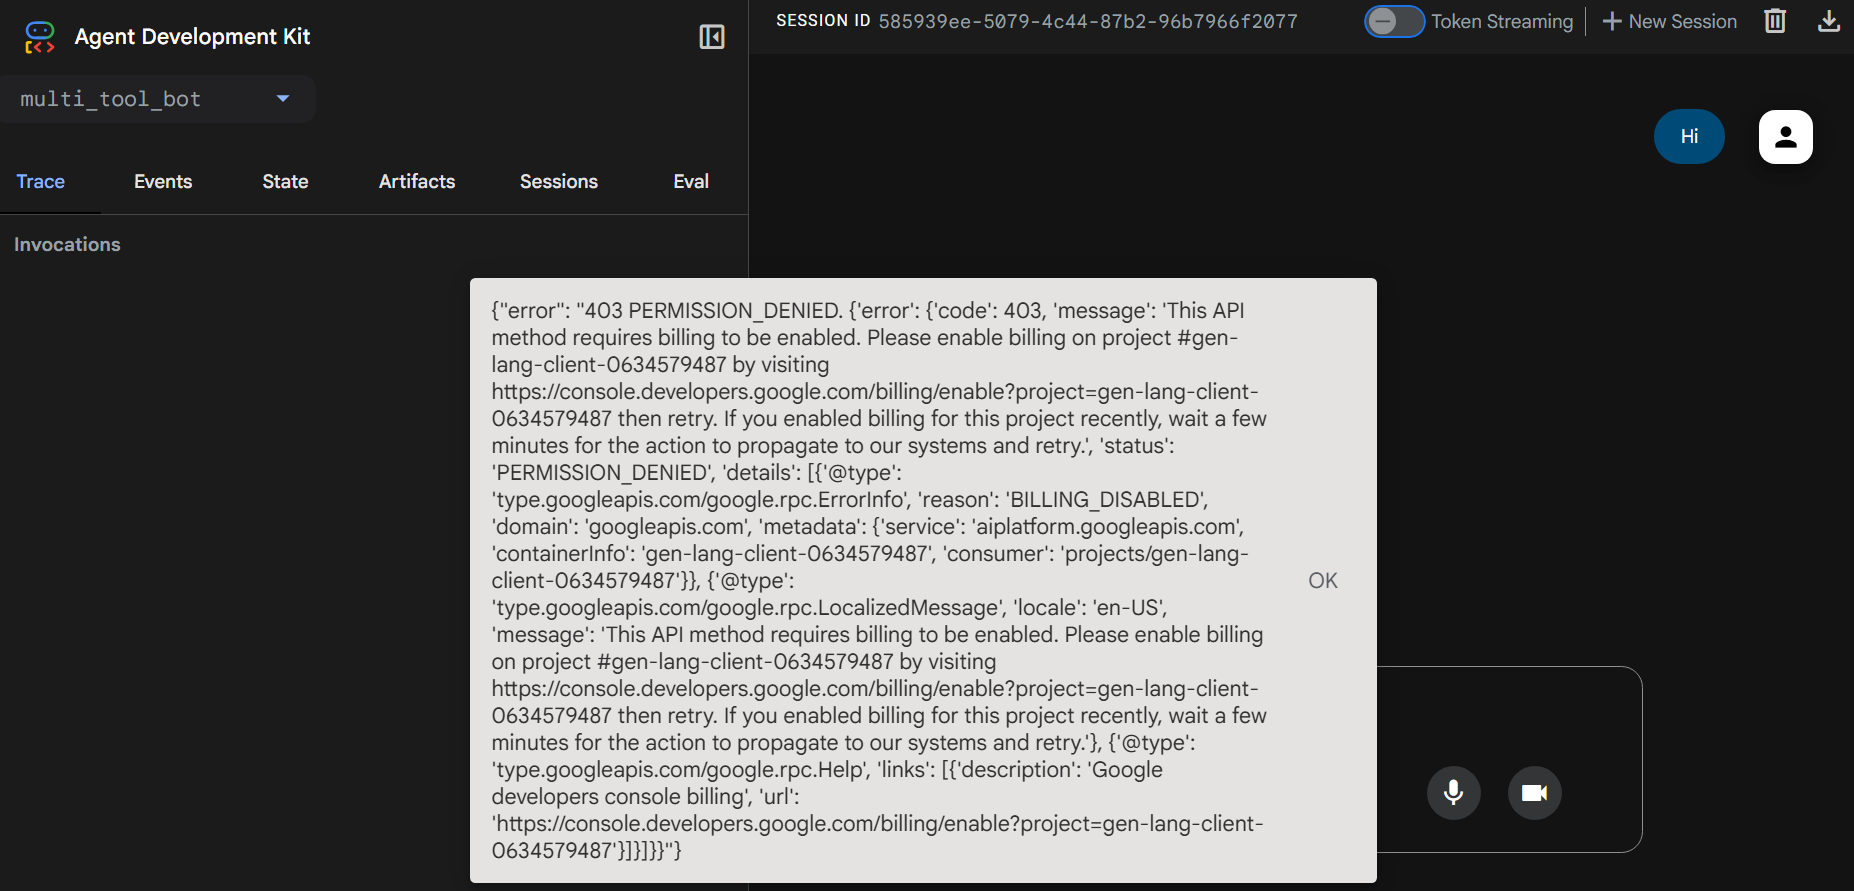 <br>

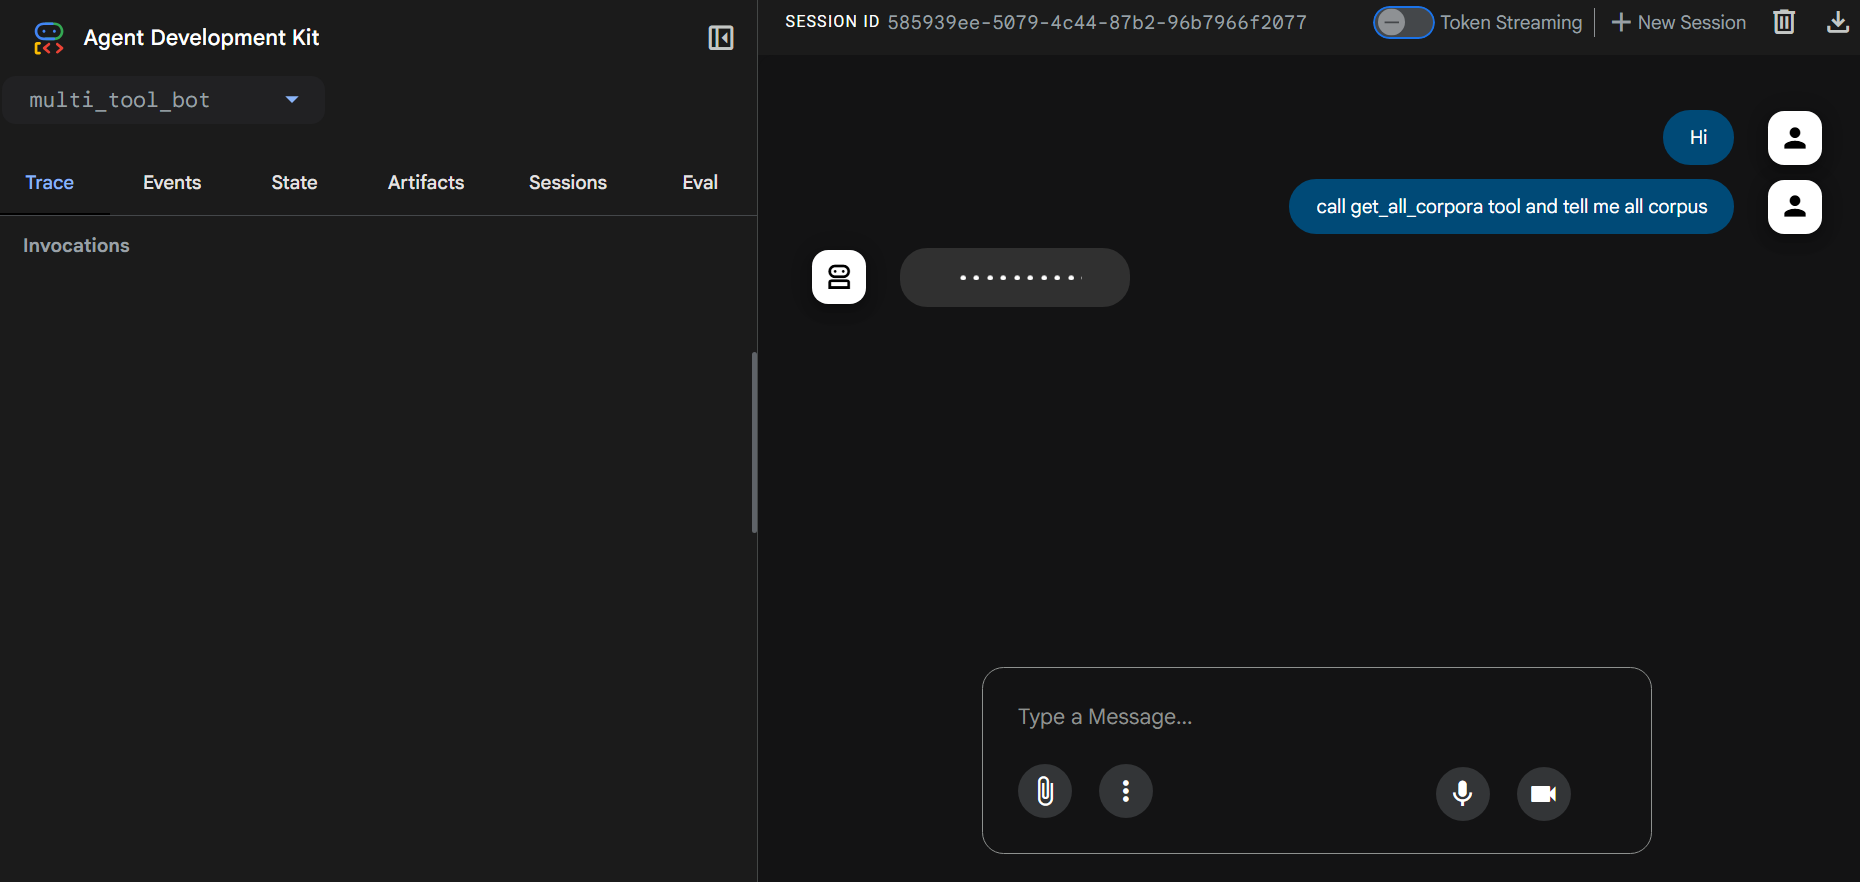 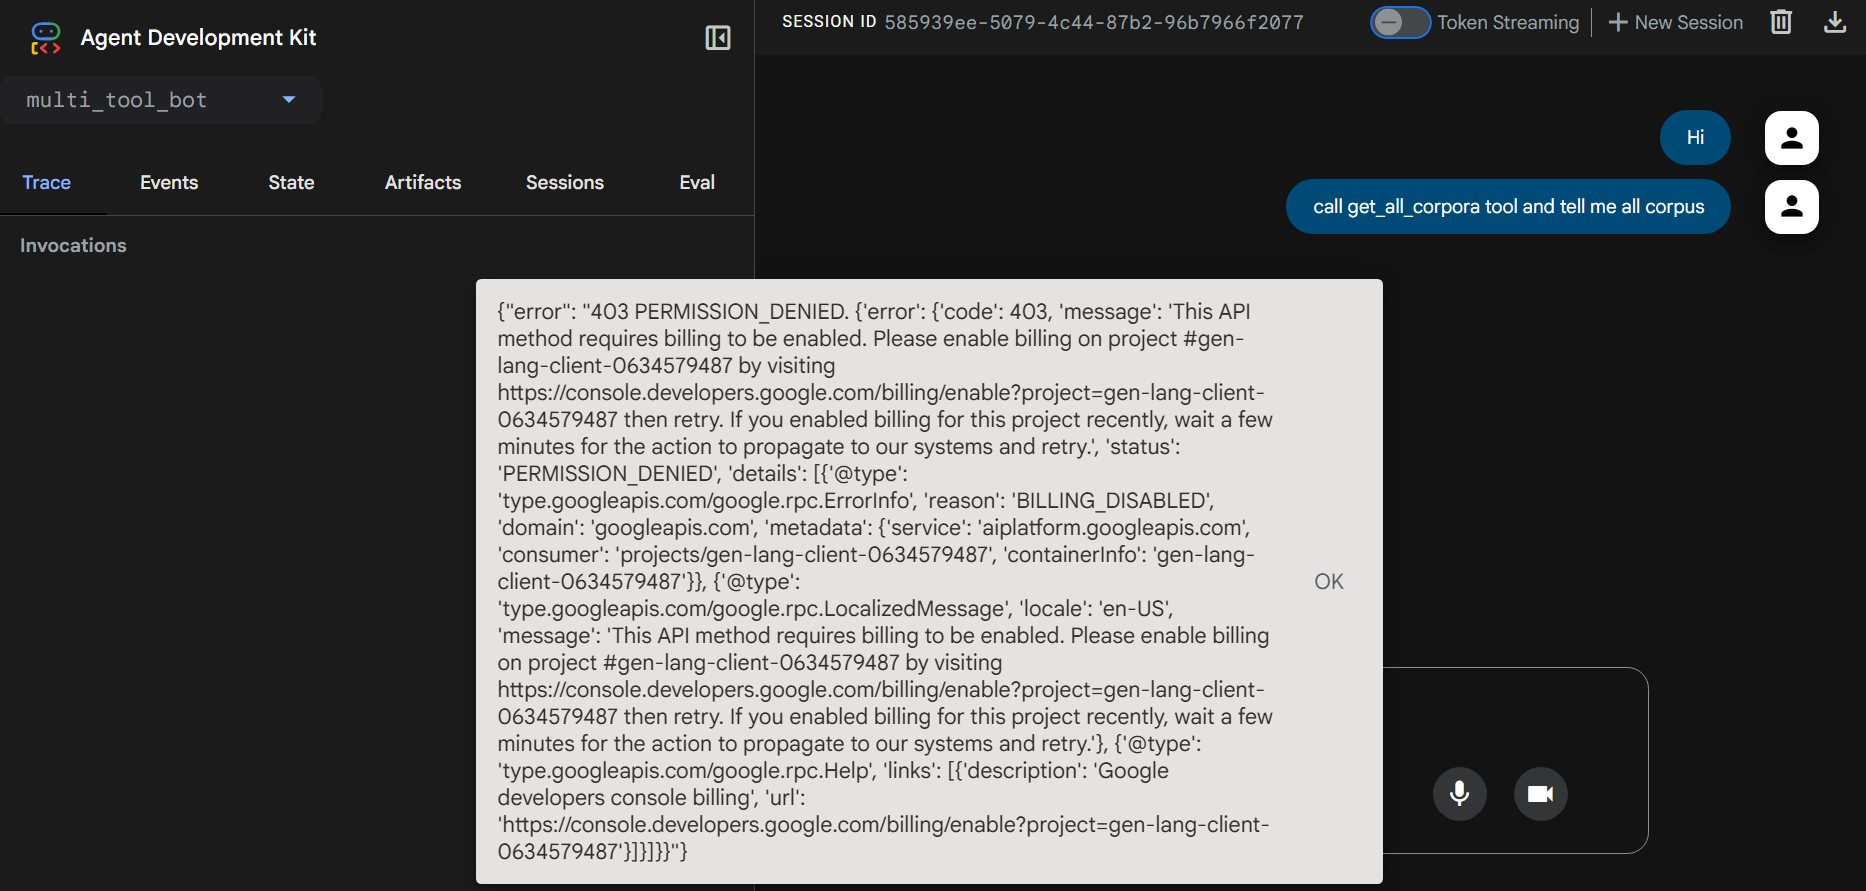 <br>

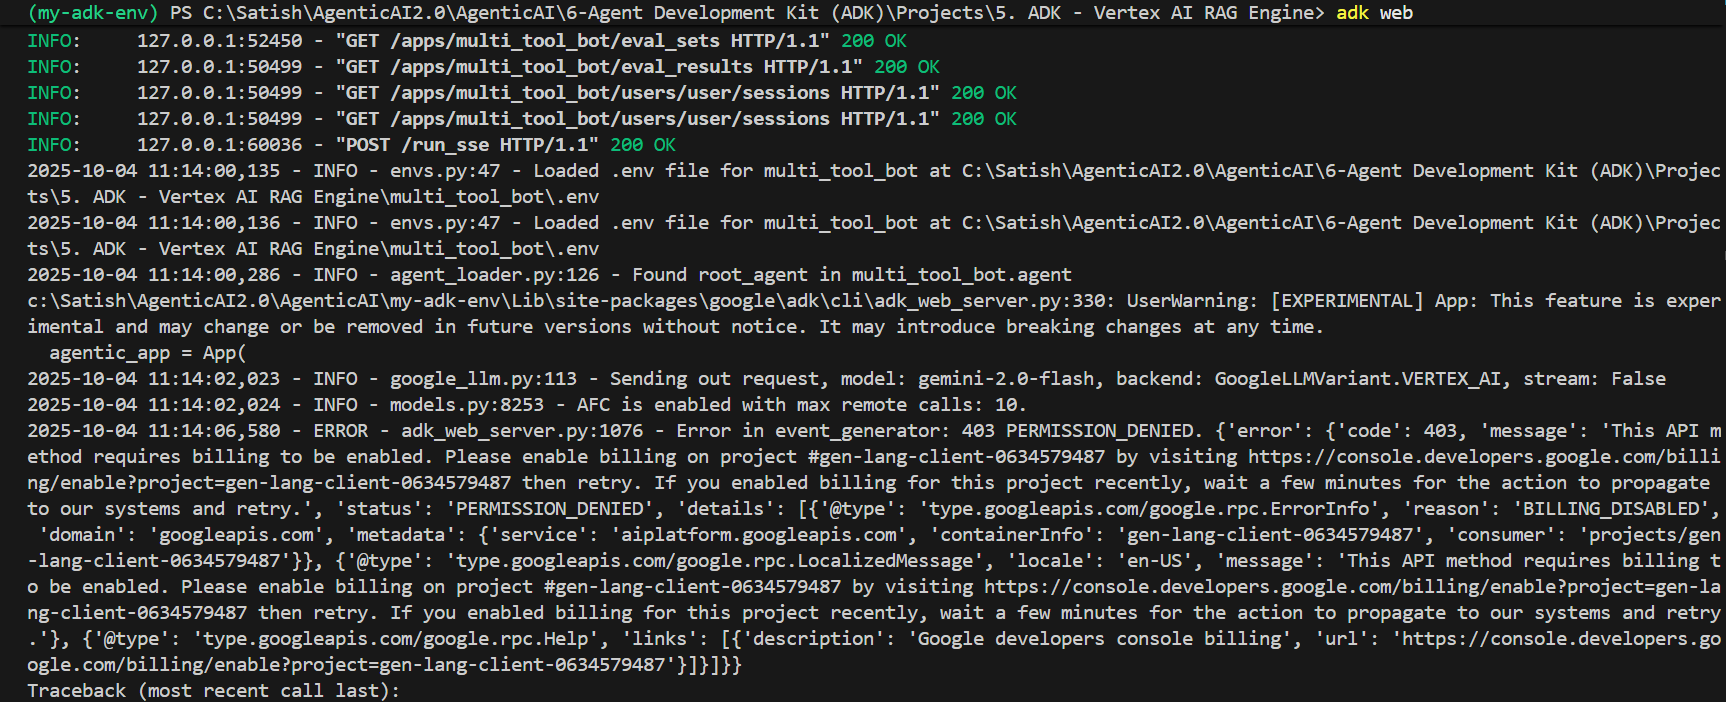 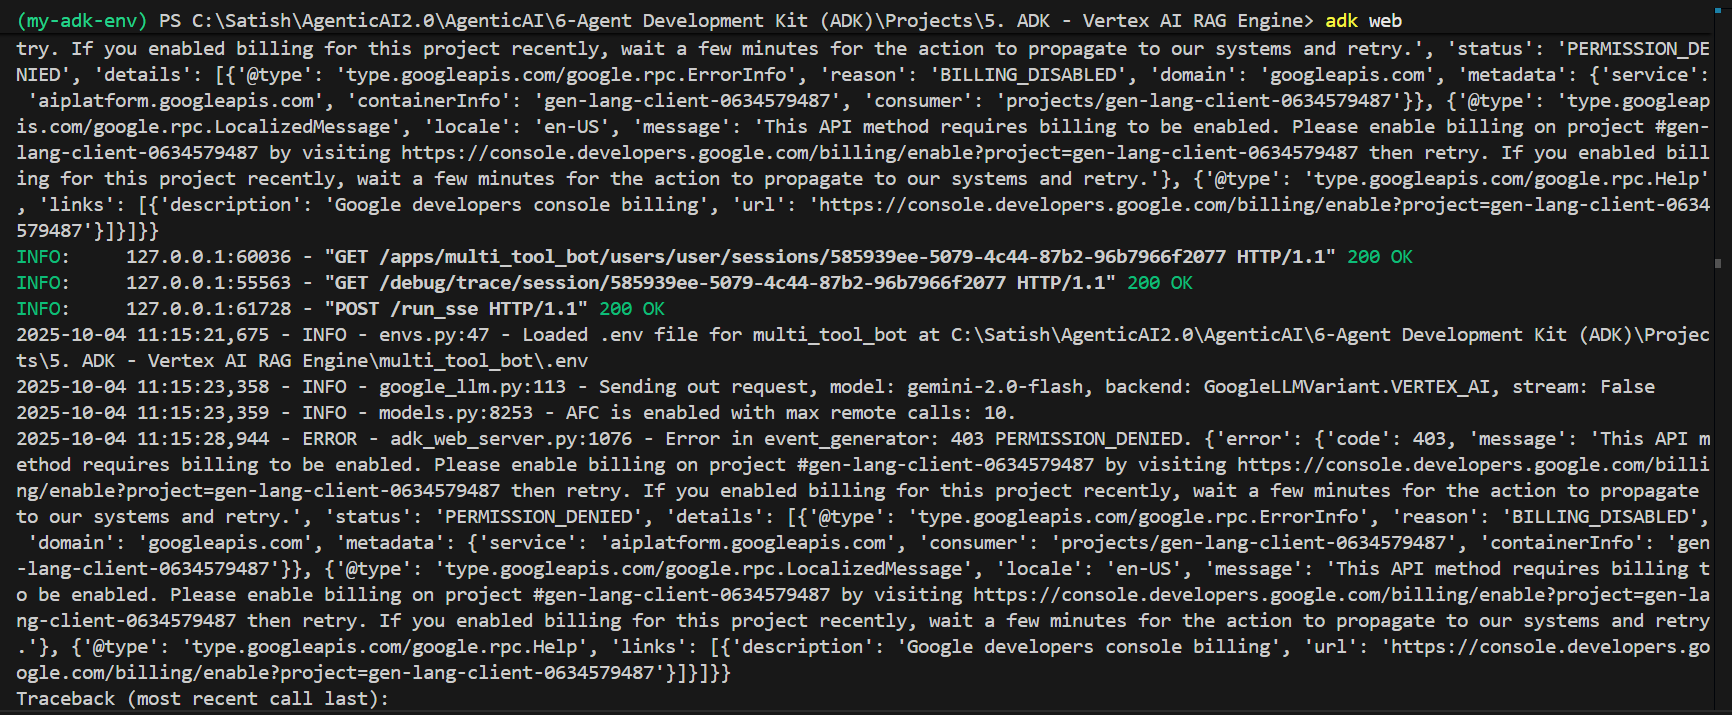 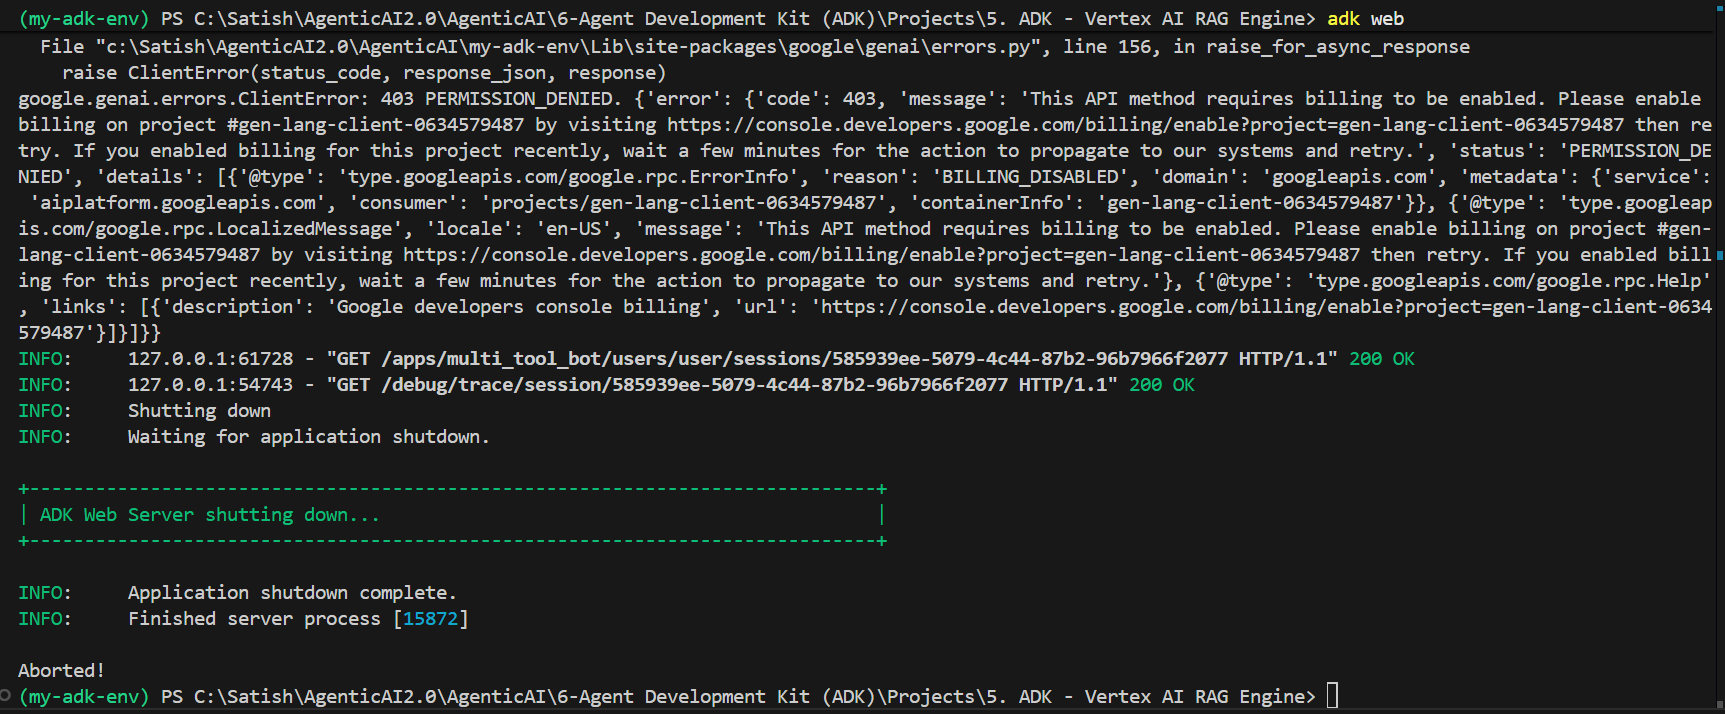 

----
